# Shariah ML Pipeline v2 — Jansen MFAT 2nd Ed. Aligned

**Markets:** US (NYSE/NASDAQ) · Malaysia (KLSE) · Hong Kong (HKEX)  
**Alpha engine:** LightGBM walk-forward CV with purge + embargo  
**Factor screening:** Alphalens IC gate before ML  
**Survivorship-bias free:** includes EODHD delisted stocks  
**Liquidity filter:** per-market ADV thresholds  
**Signal clipping:** per-date cross-section winsorisation  

> Chapters referenced: Jansen MFAT 2nd Ed. Ch. 2 (alpha factors),
> Ch. 4/12 (ML4T pipeline, IC/ICIR), Ch. 7 (walk-forward CV + embargo).


In [2]:
# ── 1. Auto-install dependencies ────────────────────────────────────────
import subprocess, sys

PKGS = [
    "pyarrow",
    "alphalens-reloaded",
    "lightgbm",
    "requests",
    "scikit-learn",
    "pandas",
    "numpy",
]

for pkg in PKGS:
    try:
        __import__(pkg.replace('-', '_').split('==')[0])
    except ImportError:
        print(f'Installing {pkg} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               pkg, '--quiet', '--break-system-packages'])

print('All dependencies OK')


Installing alphalens-reloaded ...
Installing scikit-learn ...
All dependencies OK


In [3]:
# ── 2. Configuration ────────────────────────────────────────────────────
import os, pathlib

BASE        = pathlib.Path(r'C:/Users/pc/Documents/Quant Series 2026/ml_stefan_jansen2')
EODHD_KEY   = os.environ.get('EODHD_API_KEY', '6a01d9bb03ae95.33277051')

# ── Data files
RAW_PARQUET = BASE / 'raw_ohlcv.parquet'          # adjusted OHLCV
FEAT_PARQUET= BASE / 'features_long_all.parquet'  # computed features

# ── Universe
TRAIN_START = '2010-01-01'
TRAIN_END   = '2024-12-31'
ALPHALENS_WINDOW = ('2017-01-01', '2019-12-31')   # factor screening period

# ── Walk-forward CV (Jansen Ch.7)
TARGET_HORIZON = 21   # calendar days (≈ 1 month forward return)
EMBARGO        = 21   # days after test window to avoid leakage
N_SPLITS       = 8
TRAIN_PERIOD   = 756  # ~3 years
TEST_PERIOD    = 63   # ~1 quarter
FOLD_STRIDE    = TEST_PERIOD + EMBARGO  # 84 days

# ── Liquidity (ADV in local currency, 30-day)
LIQUIDITY = {'US': 500_000, 'MY': 200_000, 'HK': 500_000}

# ── Survivorship bias
INCLUDE_DELISTED = True
MAX_DELISTED     = 300   # cap per market to keep data size manageable

# ── IC gate for Alphalens screening
IC_THRESHOLD = 0.03   # |mean IC| must exceed this

print('Config loaded')
print(f'  BASE = {BASE}')
print(f'  RAW_PARQUET  exists: {RAW_PARQUET.exists()}')
print(f'  FEAT_PARQUET exists: {FEAT_PARQUET.exists()}')


Config loaded
  BASE = C:\Users\pc\Documents\Quant Series 2026\ml_stefan_jansen2
  RAW_PARQUET  exists: True
  FEAT_PARQUET exists: True


In [16]:
import pandas as pd

a = pd.read_parquet('raw_ohlcv.parquet')
print(a.head(20))

         date       open       high        low    close    volume    ticker  \
0  2013-05-13  94.640066  94.640066  92.413241  92.5723   4055978  00001.HK   
1  2013-05-14  91.856571  92.731395  91.538453  91.9361  11592034  00001.HK   
2  2013-05-15  92.810924  92.810924  91.697512  91.9361   3678701  00001.HK   
3  2013-05-16  91.776982  92.651806  91.458864  92.0951   2417108  00001.HK   
4  2013-05-20  92.572382  93.129089  92.572382  92.8905   4219523  00001.HK   
5  2013-05-21  92.890353  94.083294  92.651765  93.2880   4376041  00001.HK   
6  2013-05-22  93.367646  95.435413  93.288116  94.3220   4546408  00001.HK   
7  2013-05-23  93.367571  93.765218  92.015571  92.0951   5165797  00001.HK   
8  2013-05-24  93.421779  93.421779  91.061821  91.8756   4042905  00001.HK   
9  2013-05-27  92.608035  92.608035  91.468744  91.6315   4039178  00001.HK   
10 2013-05-28  91.387190  92.770611  91.143056  92.4451   3223764  00001.HK   
11 2013-05-29  93.096155  93.096155  90.003800  90.7

In [4]:
# ── 3. Ticker universes ─────────────────────────────────────────────────
# Shariah-screened tickers

US_TICKERS = [
    'NVDA','AAPL','MSFT','GOOGL','AVGO','TSLA','XOM','LLY','JNJ','MU',
    'ABBV','PG','AMD','HD','CSCO','MRK','AMAT','LRCX','ORCL','GEV',
    'LIN','PEP','KLAC','ABT','TMO','TJX','CRM','TXN','COP','GILD',
    'ISRG','ADI','UBER','UNP','WELL','QCOM','BKNG','LOW','ANET','PLD',
    'ACN','DHR','MDT','NEM','SYK','VRTX','GLW','MCK','BSX','NOW',
    'ADBE','PANW','VRT','CEG','CRWD','EQIX','TT','SNDK','PWR','FCX',
    'STX','SLB','EOG','WM','JCI','MMM','ORLY','CSX','MDLZ','REGN',
    'CDNS','SHW','CMI','ROST','UPS','CL','SNPS','EMR','ITW','ECL',
    'NSC','APD','BKR','TEL','NKE','COR','CIEN','CTAS','CTVA','DASH',
    'TGT','FAST','MNST','TER','AZO','ADSK','FTNT','NXPI','CAH','MPWR',
    'BDX','IDXX','GWW','EW','COHR','FIX','RSG','CARR','EBAY','ROK',
    'NUE','WAB','HAL','GRMN','ODFL','ROP','DHI','MLM','VMC','KMB',
    'MCHP','DVN','KVUE','ADM','TPL','A','CTSH','GEHC','RMD','HSY',
    'IR','OTIS','TPR','CTRA','JBL','DOV','EXPE','XYL','CPRT','BIIB',
    'WDAY','WAT','TSCO','CHD','ON','PPG','HUBB','DXCM','STLD','NTAP',
    'VRSN','ULTA','ALB','CF','STE','VLTO','FICO','WSM','AVB','FSLR',
    'EFX','PHM','LH','MTD','PKG','WY','CHRW','EXPD','DD','AKAM',
    'EL','CDW','FFIV','WST','MAA','DECK','LULU','GPC','PNR','JBHT',
    'TRMB','INCY','NDSN','ROL','PTC','PODD','COO','HOLX','GNRC','RL',
    'IEX','ALGN','MAS','SMCI','AVY','ALLE','BBY','CLX','LII','IT',
    'GDDY','MKC','TYL','ZBRA','SWKS','BLDR','TECH','CPT','RVTY','TTD',
    'AOS','CRL','EPAM','POOL',
]

MY_TICKERS = [
    '6963.KL','5555.KL','0138.KL','5243.KL','0198.KL','2429.KL','7081.KL','7071.KL','5238.KL','5398.KL',
    '7113.KL','5099.KL','5285.KL','5210.KL','7277.KL','5216.KL','5199.KL','3336.KL','5673.KL','7253.KL',
    '5168.KL','5932.KL','5183.KL','7079.KL','0193.KL','5306.KL','5205.KL','4197.KL','8052.KL','1961.KL',
    '7036.KL','5288.KL','5218.KL','0166.KL','8664.KL','7013.KL','5296.KL','5259.KL','7204.KL','8869.KL',
    '5142.KL','0248.KL','0117.KL','0262.KL','0321.KL','9679.KL','0236.KL','5253.KL','8907.KL','5106.KL',
    '0024.KL','5878.KL','5151.KL','0395.KL','0385.KL','6998.KL','7225.KL','8877.KL','7153.KL','7108.KL',
    '0376.KL','7155.KL','5255.KL','5301.KL','0308.KL','0129.KL','5323.KL','5078.KL','6947.KL','6012.KL',
    '9431.KL','5249.KL','0055.KL','5211.KL','0245.KL','5184.KL','8494.KL','0270.KL','0179.KL','5271.KL',
    '0259.KL','5347.KL','0105.KL','5225.KL','5246.KL','1171.KL','0367.KL','4383.KL','1651.KL','0208.KL',
    '9121.KL','0359.KL','0007.KL','0175.KL','5141.KL','4863.KL','5260.KL','5031.KL','0251.KL','5071.KL',
    '7742.KL','8583.KL','0173.KL','9938.KL','9110.KL','0372.KL','0285.KL','5072.KL','5341.KL','5102.KL',
    '0153.KL','5703.KL','0052.KL','0339.KL','0187.KL','3743.KL','6888.KL','0082.KL','9695.KL','1503.KL',
    '8206.KL','5267.KL','0204.KL','3816.KL','0318.KL','0319.KL','5209.KL','0069.KL','5273.KL','7084.KL',
    '0298.KL','0252.KL','5789.KL','0246.KL','0186.KL','0163.KL','6378.KL','0157.KL','5006.KL','7244.KL',
    '0132.KL','9059.KL','5264.KL','5148.KL','4243.KL','5235.KL','0396.KL','5178.KL','5226.KL','5248.KL',
    '0293.KL','9261.KL','0083.KL','5371.KL','0390.KL','9407.KL','4634.KL','7094.KL','0135.KL','4723.KL',
    '0275.KL','7250.KL','7173.KL','5335.KL','5769.KL','0102.KL','5172.KL','0111.KL','5236.KL','5135.KL',
    '0172.KL','5219.KL','4065.KL','0181.KL','0093.KL','2054.KL','0010.KL','7160.KL','7022.KL','6556.KL',
    '0128.KL','7083.KL','5983.KL','9296.KL','0237.KL','7187.KL','2828.KL','5112.KL','0358.KL','5203.KL',
    '0234.KL','5029.KL','5292.KL','0176.KL','5050.KL','0360.KL','5681.KL','5120.KL','0072.KL','5186.KL',
    '8893.KL','6139.KL','0200.KL','0323.KL','5309.KL','0271.KL','5132.KL','0097.KL','0295.KL','0207.KL',
    '0169.KL','6033.KL','7123.KL','4847.KL','0032.KL','6599.KL','0191.KL','0180.KL','2097.KL','7103.KL',
    '0349.KL','5161.KL','7211.KL','1818.KL','0278.KL','5133.KL','5113.KL','5169.KL','1619.KL','9792.KL',
    '0240.KL','0325.KL','0368.KL','5170.KL','7252.KL','5012.KL','0038.KL','3158.KL','8311.KL','0209.KL',
    '0025.KL','0343.KL','5286.KL','5125.KL','0347.KL','0146.KL','5115.KL','5315.KL','0045.KL','0386.KL',
    '7154.KL','0283.KL','1538.KL','0068.KL','5070.KL','8338.KL','0001.KL','9741.KL','0348.KL','5257.KL',
    '0389.KL','0375.KL','5649.KL','5302.KL','2127.KL','5140.KL','5401.KL','6874.KL','7200.KL','5318.KL',
    '0331.KL','5098.KL','5171.KL','5147.KL','0392.KL','0217.KL','0026.KL','5343.KL','0160.KL','0192.KL',
    '5094.KL','7018.KL','0212.KL','0320.KL','1589.KL','5348.KL','0326.KL','5331.KL','3611.KL','3689.KL',
    '7498.KL','5038.KL','0223.KL','9237.KL','4235.KL','0028.KL','5272.KL','0039.KL','5200.KL','1368.KL',
    '7161.KL','7145.KL','7163.KL','0313.KL','7208.KL','2739.KL','8567.KL','0263.KL','7100.KL','0351.KL',
    '5330.KL','0233.KL','0307.KL','4251.KL','7228.KL','0127.KL','5068.KL','4731.KL','5126.KL','7184.KL',
    '2445.KL','7181.KL','0080.KL','4081.KL','0079.KL','7209.KL','7095.KL','0110.KL','3069.KL','9474.KL',
    '7237.KL','0288.KL','0373.KL','0337.KL','0183.KL','0290.KL','5116.KL','0327.KL','2089.KL','0365.KL',
    '2259.KL','7052.KL','0311.KL','0265.KL','9326.KL','5322.KL','5215.KL','7133.KL','0243.KL','5162.KL',
    '3557.KL','7090.KL','8885.KL','5275.KL','0156.KL','0291.KL','0065.KL','0317.KL','5080.KL','5316.KL',
    '7007.KL','6807.KL','8028.KL','0357.KL','0035.KL','0241.KL','0040.KL','0222.KL','1724.KL','9008.KL',
    '0203.KL','7803.KL','0282.KL','1481.KL','0267.KL','7089.KL','6262.KL','0178.KL','5195.KL','7105.KL',
    '5152.KL','0118.KL','9083.KL','0096.KL','0284.KL','7174.KL','0329.KL','5308.KL','5062.KL','0197.KL',
    '0377.KL','0292.KL','0381.KL','2224.KL','0379.KL','0084.KL','7167.KL','0206.KL','9776.KL','0048.KL',
    '0011.KL','0342.KL','0378.KL','7219.KL','0078.KL','5143.KL','7212.KL','5027.KL','0258.KL','5084.KL',
    '0300.KL','5138.KL','5320.KL','5145.KL','0195.KL','5157.KL','8591.KL','9459.KL','7080.KL','0335.KL',
    '5305.KL','9075.KL','7050.KL','5066.KL','0350.KL','7240.KL','0023.KL','0205.KL','0049.KL','5077.KL',
    '0260.KL','0218.KL','6483.KL','5657.KL','0333.KL','9571.KL','0161.KL','0304.KL','5020.KL','1198.KL',
    '2593.KL','5024.KL','5332.KL','5173.KL','0126.KL','0355.KL','0155.KL','9172.KL','0107.KL','7047.KL',
    '0147.KL','4405.KL','7051.KL','5005.KL','5289.KL','0306.KL','6971.KL','7031.KL','0296.KL','0168.KL',
    '0828EA.KL','0256.KL','0012.KL','3662.KL','0490.KL','5276.KL','0361.KL','7115.KL','5054.KL','7004.KL',
    '5090.KL','5237.KL','0145.KL','7107.KL','0316.KL','7017.KL','5101.KL','7231.KL','6718.KL','3042.KL',
    '8303.KL','7501.KL','0091.KL','0211.KL','7757.KL','5166.KL','7221.KL','7215.KL','0228.KL','0279.KL',
    '6041.KL','7595.KL','5136.KL','7773.KL','5056.KL','7765.KL','0305.KL','7087.KL','0272.KL','0070.KL',
    '7035.KL','0051.KL','0136.KL','0101.KL','9962.KL','7285.KL','5075.KL','8435.KL','8702.KL','0301.KL',
    '5827.KL','3867.KL','6114.KL','6769.KL','5204.KL','7152.KL','5042.KL','8982.KL','7245.KL','7178.KL',
    '0312.KL','7198.KL','5095.KL','4286.KL','5321.KL','5239.KL','0131.KL','7943.KL','0170.KL','0133.KL',
    '7172.KL','0253.KL','0352.KL','9946.KL','5310.KL','4596.KL','7117.KL','9601.KL','5182.KL','7168.KL',
    '9954.KL','5022.KL','8966.KL','0022.KL','7130.KL','0369.KL','0249.KL','4707.KL','4995.KL','5160.KL',
    '5235SS.KL','5191.KL','5010.KL','5314.KL','5603.KL','7074.KL','0345.KL','5247.KL','7230.KL','3301.KL',
    '0341.KL','5291.KL','5016.KL','0353.KL','0257.KL','0302.KL','7210.KL','5104.KL','7176.KL','9393.KL',
    '2062.KL','0165.KL','0229.KL','7197.KL','0227.KL','0188.KL','7232.KL','0143.KL','7247.KL','0162.KL',
    '6491.KL','7120.KL','5207.KL','5196.KL','0827EA.KL','0235.KL','0008.KL','7016.KL','5192.KL','8931.KL',
    '3395.KL','5345.KL','5277.KL','7140.KL','0383.KL','6181.KL','0046.KL','7214.KL','0366.KL','9881.KL',
    '5041.KL','0550.KL','0113.KL','5049.KL','2291.KL','0238.KL','0221.KL','9091.KL','7131.KL','0190.KL',
    '7134.KL','7203.KL','5298.KL','2607.KL','7128.KL','0213.KL','6432.KL','5208.KL','5252.KL','5238A.KL',
    '5797.KL','0289.KL','7157.KL','0281.KL','3107.KL','2135.KL','5843.KL','7170.KL','5131.KL','5197.KL',
    '7249.KL','5011.KL','0043.KL','7382.KL','8478.KL','5001.KL','0202.KL','6211.KL','0201.KL','7412.KL',
    '5149.KL','5009.KL','0086.KL','7229.KL','1996.KL','7162.KL','0089.KL','5436.KL','5036.KL','8486.KL',
    '9598.KL','7029.KL','7191.KL','9963.KL','7132.KL','6815.KL','5087.KL','5100.KL','0081.KL','6351.KL',
    '0231.KL','5032.KL','7091.KL','3026.KL','5576.KL','0158.KL','0064.KL','7086.KL','8346.KL','5015.KL',
    '5037.KL','7676.KL','3573.KL','5223.KL','0152.KL','7014.KL','7854.KL','7218.KL','5340.KL','0839EA.KL',
    '0174.KL','7033.KL','7471.KL','0824EA.KL','5065.KL','0232.KL','5035.KL','7062.KL','9997.KL','0821EA.KL',
    '8079.KL','5085.KL','7020.KL','9113.KL','7234.KL','4022.KL','7239.KL','0330.KL','0332.KL',
]

HK_TICKERS = [
    '1735.HK','1193.HK','1548.HK','1478.HK','1951.HK','2343.HK','1396.HK','2585.HK','0990.HK','0565.HK',
    '0303.HK','2342.HK','0220.HK','0144.HK','0551.HK','2096.HK','0570.HK','2315.HK','2158.HK','2076.HK',
    '2602.HK','1199.HK','1910.HK','1179.HK','1789.HK','2232.HK','1757.HK','1066.HK','3868.HK','8299.HK',
    '2623.HK','2570.HK','1313.HK','1651.HK','6936.HK','1645.HK','0867.HK','2273.HK','1368.HK','2302.HK',
    '3788.HK','0975.HK','1167.HK','0512.HK','1440.HK','1617.HK','1913.HK','0863.HK','1302.HK','0081.HK',
    '1783.HK','9900.HK','0038.HK','2522.HK','0087.HK','0590.HK','2172.HK','0506.HK','6063.HK','8637.HK',
    '1882.HK','1716.HK','1875.HK','1523.HK','1675.HK','2442.HK','2285.HK','0004.HK','3306.HK','6110.HK',
    '1720.HK','6808.HK','1851.HK','0784.HK','1710.HK','3613.HK','1501.HK','2291.HK','1873.HK','1836.HK',
    '0264.HK','2495.HK','3669.HK','2005.HK','0567.HK','2121.HK','0010.HK','2469.HK','2225.HK','0178.HK',
    '01810.HK','09988.HK','00175.HK','00857.HK','06181.HK','02269.HK','00941.HK','01347.HK','03939.HK','01801.HK',
    '02099.HK','01208.HK','00669.HK','00992.HK','02331.HK','02020.HK','01833.HK','00762.HK','01888.HK','02507.HK',
    '01258.HK','01316.HK','03668.HK','01585.HK','00322.HK','03800.HK','01579.HK','00300.HK','00012.HK','00425.HK',
    '02018.HK','00354.HK','02268.HK','03931.HK','01109.HK','00268.HK','03808.HK','00027.HK','00522.HK','01860.HK',
    '00780.HK','01177.HK','01357.HK','03692.HK','00002.HK','00189.HK','09901.HK','00688.HK','02313.HK','01385.HK',
    '01099.HK','01929.HK','00788.HK','02400.HK','03738.HK','02688.HK','02155.HK','02013.HK','00019.HK','01415.HK',
    '00853.HK','00772.HK','00066.HK','03759.HK','01773.HK','00881.HK','00666.HK','00467.HK','01277.HK','00340.HK',
    '01952.HK','02432.HK','00960.HK','00631.HK','00868.HK','00696.HK','03998.HK','01308.HK','00101.HK','02276.HK',
    '00826.HK',
]

MARKET_MAP = {t: 'US' for t in US_TICKERS}
MARKET_MAP.update({t: 'MY' for t in MY_TICKERS})
MARKET_MAP.update({t: 'HK' for t in HK_TICKERS})

ALL_TICKERS = US_TICKERS + MY_TICKERS + HK_TICKERS
print(f'Universe: {len(ALL_TICKERS)} tickers  '
      f'(US={len(US_TICKERS)}, MY={len(MY_TICKERS)}, HK={len(HK_TICKERS)})')


Universe: 1084 tickers  (US=214, MY=699, HK=171)


In [5]:
# ── 4. EODHD downloader (with delisted stocks) ──────────────────────────
import requests, time, io
import pandas as pd
import numpy as np

EOD_BASE = 'https://eodhd.com/api'

def fetch_eod(ticker: str, start: str, end: str, retries: int = 3) -> pd.DataFrame:
    '''Download adjusted daily OHLCV from EODHD for one ticker.'''
    sym, exch = (ticker.split('.') + ['US'])[:2]
    url = (f'{EOD_BASE}/eod/{sym}.{exch}'
           f'?api_token={EODHD_KEY}&fmt=json'
           f'&from={start}&to={end}&period=d')
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            data = r.json()
            if not data:
                return pd.DataFrame()
            df = pd.DataFrame(data)
            df['date'] = pd.to_datetime(df['date'])
            df = df.set_index('date').sort_index()
            # Adjust OHLC using adjusted_close / close ratio
            if 'adjusted_close' in df.columns and 'close' in df.columns:
                ratio = df['adjusted_close'] / df['close'].replace(0, np.nan)
                for col in ['open', 'high', 'low']:
                    df[col] = df[col] * ratio
                df['close'] = df['adjusted_close']
            df = df[['open', 'high', 'low', 'close', 'volume']].copy()
            df.index.name = 'date'
            return df
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f'  [WARN] {ticker}: {e}')
                return pd.DataFrame()


EXCHANGE_CODES = {'US': 'US', 'MY': 'KLSE', 'HK': 'HK'}

def get_delisted(market: str, max_stocks: int = 300) -> list[str]:
    '''
    Fetch delisted tickers from EODHD exchange symbol list.
    Survivorship-bias: Jansen MFAT 2nd Ed., Ch.2 p.52.
    '''
    exch = EXCHANGE_CODES.get(market, market)
    url  = (f'{EOD_BASE}/exchange-symbol-list/{exch}'
            f'?api_token={EODHD_KEY}&fmt=json&delisted=1')
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        data = r.json()
        tickers = [f"{row['Code']}.{exch}" for row in data
                   if row.get('Type') in ('Common Stock', 'ETF', None)]
        print(f'  {market}: {len(tickers)} delisted found, capping at {max_stocks}')
        return tickers[:max_stocks]
    except Exception as e:
        print(f'  [WARN] Could not fetch delisted for {market}: {e}')
        return []


print('Downloader functions defined')


Downloader functions defined


In [14]:
# ── 5. Download raw OHLCV → Parquet ─────────────────────────────────────
# Skips download if RAW_PARQUET already exists.
# Set FORCE_DOWNLOAD = True to re-download.

FORCE_DOWNLOAD = False

if RAW_PARQUET.exists() and not FORCE_DOWNLOAD:
    print(f'RAW_PARQUET already exists ({RAW_PARQUET.stat().st_size/1e6:.1f} MB). Skipping download.')
    print('Set FORCE_DOWNLOAD = True to re-download.')
else:
    print(f'Starting download: {TRAIN_START} → {TRAIN_END}')

    # ── 5a. Live tickers
    live_tickers = list(ALL_TICKERS)

    # ── 5b. Delisted tickers (survivorship-bias correction)
    delisted_tickers = []
    if INCLUDE_DELISTED:
        print('Fetching delisted tickers ...')
        for mkt in ['US', 'MY', 'HK']:
            dl = get_delisted(mkt, max_stocks=MAX_DELISTED)
            delisted_tickers.extend(dl)
        print(f'  Total delisted: {len(delisted_tickers)}')

    all_download = live_tickers + [t for t in delisted_tickers if t not in live_tickers]
    print(f'Downloading {len(all_download)} tickers total ...')

    frames = []
    for i, ticker in enumerate(all_download):
        df = fetch_eod(ticker, TRAIN_START, TRAIN_END)
        if df.empty:
            continue
        df['ticker'] = ticker
        # mark survivorship status
        df['delisted'] = ticker in delisted_tickers
        df['market']   = MARKET_MAP.get(ticker, 'US')
        frames.append(df)
        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{len(all_download)} done ...')
        time.sleep(0.05)   # gentle rate-limit

    raw = pd.concat(frames).reset_index()
    raw.to_parquet(RAW_PARQUET, engine='pyarrow', compression='snappy', index=False)
    print(f'Saved {len(raw):,} rows → {RAW_PARQUET} ({RAW_PARQUET.stat().st_size/1e6:.1f} MB)')


RAW_PARQUET already exists (67.6 MB). Skipping download.
Set FORCE_DOWNLOAD = True to re-download.


In [15]:
print(raw.head(20))

NameError: name 'raw' is not defined

In [7]:
# ── 6. Feature engineering (per-ticker groupby) + liquidity filter ───────
import warnings
warnings.filterwarnings('ignore')
try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    import subprocess, sys as _sys
    subprocess.check_call([_sys.executable, '-m', 'pip', 'install', 'tqdm', '-q'])
    from tqdm.auto import tqdm as _tqdm

def compute_features(g: pd.DataFrame) -> pd.DataFrame:
    '''Compute alpha features for one ticker group.'''
    c = g['close']; v = g['volume']
    h = g['high'];  l = g['low']

    out = pd.DataFrame(index=g.index)
    out['close']   = c

    # ── Returns
    out['ret_1d']  = c.pct_change(1)
    out['log_ret_1d'] = np.log(c / c.shift(1))
    out['ret_5d']  = c.pct_change(5)
    out['ret_10d'] = c.pct_change(10)
    out['ret_21d'] = c.pct_change(21)
    out['ret_63d'] = c.pct_change(63)

    # ── Momentum
    delta = c.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / loss.replace(0, np.nan)
    out['rsi_14'] = 100 - (100 / (1 + rs))
    out['roc_21'] = (c / c.shift(21) - 1)

    # ── Trend
    sma50  = c.rolling(50).mean()
    sma200 = c.rolling(200).mean()
    out['close_vs_sma50']  = (c / sma50 - 1)
    out['close_vs_sma200'] = (c / sma200 - 1)

    # ── Volatility
    lr = np.log(c / c.shift(1))
    out['vol_10d'] = lr.rolling(10).std()
    out['vol_21d'] = lr.rolling(21).std()
    out['vol_63d'] = lr.rolling(63).std()

    # ── ATR %
    tr  = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
    out['atr_pct'] = tr.rolling(14).mean() / c

    # ── Bollinger Bands
    sma20  = c.rolling(20).mean()
    std20  = c.rolling(20).std()
    upper  = sma20 + 2 * std20
    lower  = sma20 - 2 * std20
    out['bb_width']    = (upper - lower) / sma20.replace(0, np.nan)
    out['bb_position'] = (c - lower) / (upper - lower).replace(0, np.nan)

    # ── Volume features
    vol_sma20 = v.rolling(20).mean()
    vol_sma5  = v.rolling(5).mean()
    out['vol_ratio'] = v / vol_sma20.replace(0, np.nan)
    out['vol_mom']   = vol_sma5.pct_change(20)

    # ── Forward return targets
    out['target_5d']        = c.shift(-5)  / c - 1
    out['target_21d']       = c.shift(-21) / c - 1
    out['target_direction'] = (out['target_21d'] > 0).astype(int)

    return out


if FEAT_PARQUET.exists():
    print(f'FEAT_PARQUET exists ({FEAT_PARQUET.stat().st_size/1e6:.1f} MB). Loading ...')
    feat_df = pd.read_parquet(FEAT_PARQUET)
    feat_df['date'] = pd.to_datetime(feat_df['date'])
    print(f'  Loaded {len(feat_df):,} rows, {feat_df.shape[1]} cols')
else:
    print('Computing features for 1,056 tickers — this takes ~10-20 min ...')
    raw = pd.read_parquet(RAW_PARQUET)
    raw['date'] = pd.to_datetime(raw['date'])
    raw = raw.set_index('date').sort_index()

    tickers = raw['ticker'].unique()
    feat_frames = []
    for ticker in _tqdm(tickers, desc='Feature eng'):
        g = raw[raw['ticker'] == ticker].sort_index()
        mkt = g['market'].iloc[0]
        f   = compute_features(g)
        f['ticker']   = ticker
        f['market']   = mkt
        f['delisted'] = g['delisted'].iloc[0]

        # ── Liquidity filter: rolling 30-day ADV
        adv30 = (g['close'] * g['volume']).rolling(30).mean()
        liq_threshold = LIQUIDITY.get(mkt, 500_000)
        f = f[adv30 >= liq_threshold]
        feat_frames.append(f)

    feat_df = pd.concat(feat_frames)
    feat_df.index.name = 'date'
    feat_df = feat_df.reset_index()
    feat_df['date'] = pd.to_datetime(feat_df['date'])

    # ── Sanitise: replace ±inf with NaN
    float_cols = feat_df.select_dtypes(include=[np.floating]).columns
    feat_df[float_cols] = feat_df[float_cols].replace([np.inf, -np.inf], np.nan)

    feat_df.to_parquet(FEAT_PARQUET, engine='pyarrow', compression='snappy', index=False)
    print(f'  Saved {len(feat_df):,} rows → {FEAT_PARQUET} ({FEAT_PARQUET.stat().st_size/1e6:.1f} MB)')

print(f'feat_df: {feat_df.shape}  |  cols: {list(feat_df.columns)}')


FEAT_PARQUET exists (271.2 MB). Loading ...
  Loaded 1,641,043 rows, 26 cols
feat_df: (1641043, 26)  |  cols: ['date', 'close', 'ret_1d', 'log_ret_1d', 'ret_5d', 'ret_10d', 'ret_21d', 'ret_63d', 'rsi_14', 'roc_21', 'close_vs_sma50', 'close_vs_sma200', 'vol_10d', 'vol_21d', 'vol_63d', 'atr_pct', 'bb_width', 'bb_position', 'vol_ratio', 'vol_mom', 'target_5d', 'target_21d', 'target_direction', 'ticker', 'market', 'delisted']


In [12]:
print(feat_df.head(20))
a = feat_df.head(200)
a = a.to_csv('FEAT_CSV.csv', index=False)

         date    close    ret_1d  log_ret_1d    ret_5d   ret_10d   ret_21d  \
0  2013-06-25  82.2728  0.004970    0.004958 -0.068202 -0.020350 -0.104520   
1  2013-06-26  83.5749  0.015827    0.015703 -0.030218  0.004891 -0.087924   
2  2013-06-27  84.3072  0.008762    0.008724  0.014691  0.003875 -0.088030   
3  2013-06-28  85.6093  0.015445    0.015327  0.046766  0.004775 -0.056503   
4  2013-07-02  84.9584 -0.007603   -0.007632  0.037775 -0.038674 -0.050910   
5  2013-07-03  83.1681 -0.021073   -0.021298  0.010882 -0.058062 -0.069216   
6  2013-07-04  84.2261  0.012721    0.012641  0.007792 -0.022662 -0.051326   
7  2013-07-05  85.6093  0.016422    0.016289  0.015445  0.030362 -0.033089   
8  2013-07-08  84.2261 -0.016157   -0.016289 -0.016157  0.029853 -0.021738   
9  2013-07-09  84.2261  0.000000    0.000000 -0.008620  0.028830 -0.021738   
10 2013-07-10  86.4230  0.026083    0.025749  0.039136  0.050444  0.022137   
11 2013-07-11  87.6440  0.014128    0.014029  0.040580  0.048688

In [6]:
# ── 7. Alphalens factor screening (Jansen Ch.4 / Ch.12) ─────────────────
# Screens which features have IC > threshold on a held-out 2017-2019 window.
# Only features that pass the IC gate are used in ML.

import alphalens as al
from alphalens.utils import get_clean_factor_and_forward_returns



FEATURE_COLS = [
    'ret_1d','log_ret_1d','ret_5d','ret_10d','ret_21d','ret_63d',
    'rsi_14','roc_21',
    'close_vs_sma50','close_vs_sma200',
    'vol_10d','vol_21d','vol_63d',
    'atr_pct','bb_width','bb_position',
    'vol_ratio','vol_mom',
]

# ── Prepare alphalens inputs on screening window
al_start, al_end = ALPHALENS_WINDOW
fd = feat_df.copy()

# Handle 'date' as either a column or already the DatetimeIndex
if 'date' in fd.columns:
    fd['date'] = pd.to_datetime(fd['date'])
    fd = fd.set_index('date').sort_index()
elif fd.index.name == 'date':
    fd.index = pd.to_datetime(fd.index)
    fd = fd.sort_index()
else:
    raise KeyError(f"'date' not found. Columns: {list(fd.columns)}, Index name: {fd.index.name}")

fd_screen = fd.loc[al_start:al_end]

# ── Prices panel: date × ticker
prices = fd_screen.pivot_table(index='date', columns='ticker', values='close')

passed_features = []
failed_features = []

for feat in FEATURE_COLS:
    try:
        factor_series = fd_screen.set_index('ticker', append=True)[feat].dropna()
        factor_series = factor_series[~factor_series.index.duplicated()]
        factor_data = get_clean_factor_and_forward_returns(
            factor_series,
            prices,
            periods=(5, 21),
            quantiles=5,
            max_loss=0.35,
        )
        ic = al.performance.factor_information_coefficient(factor_data)
        mean_ic = ic.abs().mean().max()  # take best horizon
        if mean_ic >= IC_THRESHOLD:
            passed_features.append(feat)
            print(f'  PASS  {feat:<22}  |IC|={mean_ic:.4f}')
        else:
            failed_features.append(feat)
            print(f'  fail  {feat:<22}  |IC|={mean_ic:.4f}')
    except Exception as e:
        failed_features.append(feat)
        print(f'  ERR   {feat:<22}  {e}')

if not passed_features:
    print('[WARN] No features passed IC gate — using all features as fallback.')
    passed_features = FEATURE_COLS

print(f'\nScreened features: {len(passed_features)}/{len(FEATURE_COLS)} passed |IC| ≥ {IC_THRESHOLD}')
print('Passed:', passed_features)


Dropped 2.5% entries from factor data: 2.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
  PASS  ret_1d                  |IC|=0.0893
Dropped 2.5% entries from factor data: 2.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
  PASS  log_ret_1d              |IC|=0.0893
Dropped 2.5% entries from factor data: 2.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
  PASS  ret_5d                  |IC|=0.0848
Dropped 2.5% entries from factor data: 2.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 35.0%, not exceeded: OK!
  PASS  ret_10d                 |IC|=0.0821
Dropped 2.5% entries from factor dat

In [7]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 8 — Walk-forward CV with purge + embargo (Jansen Ch.7)
# ═══════════════════════════════════════════════════════════════════════
 
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LassoCV
 
# ── Build ML matrix: keep date + ticker as COLUMNS (not index)
ml_start = '2020-01-01'
fd2 = feat_df.copy()
fd2['date'] = pd.to_datetime(fd2['date'])
fd2 = fd2.sort_values('date').reset_index(drop=True)  # clean integer index
fd2 = fd2[fd2['date'] >= ml_start]
fd2 = fd2.dropna(subset=passed_features + ['target_21d'])
fd2 = fd2.reset_index(drop=True)
 
X_all = fd2[passed_features].copy()
y_all = fd2['target_21d'].copy()
 
# ── Unique sorted dates for the CV to split on
unique_dates = np.sort(fd2['date'].unique())
# Map: for each unique date → row indices in fd2
date_to_rows = {d: g.index.tolist() for d, g in fd2.groupby('date')}
 
print(f'ML matrix: {X_all.shape[0]:,} rows × {X_all.shape[1]} features')
print(f'Unique trading dates: {len(unique_dates)}')
print(f'Avg tickers/date: {len(fd2) / len(unique_dates):.0f}')
 
 
class MultipleTimeSeriesCV:
    """
    Walk-forward CV that splits on UNIQUE DATES (Jansen MFAT 2e, Ch.7).
 
    Parameters are in trading days (unique dates), not flat rows.
    All tickers on a given date are always in the same fold.
    Purge gap between train_end and test_start prevents look-ahead.
    Embargo gap after test_end prevents leakage from lagged targets.
    """
    def __init__(self, n_splits, train_period, test_period, purge, embargo):
        self.n_splits     = n_splits
        self.train_period = train_period   # trading days
        self.test_period  = test_period    # trading days
        self.purge        = purge          # trading days
        self.embargo      = embargo        # trading days
 
    def split(self, X, y=None, groups=None, dates=None, date_to_rows=None):
        """
        Parameters
        ----------
        dates : array of sorted unique dates
        date_to_rows : dict mapping each date → list of row indices
        """
        n_dates = len(dates)
        stride  = self.test_period + self.embargo
 
        # Walk backwards from the end to place n_splits test windows
        last_test_end = n_dates
        for i in range(self.n_splits - 1, -1, -1):
            test_end   = last_test_end - i * stride
            test_start = test_end - self.test_period
            train_end  = test_start - self.purge    # purge gap
            train_start = max(0, train_end - self.train_period)
 
            if train_start >= train_end or test_start >= test_end:
                continue
            if train_end <= 0 or test_start < 0:
                continue
 
            # Convert date-indices → row-indices
            train_dates = dates[train_start:train_end]
            test_dates  = dates[test_start:test_end]
 
            train_rows = []
            for d in train_dates:
                train_rows.extend(date_to_rows[d])
            test_rows = []
            for d in test_dates:
                test_rows.extend(date_to_rows[d])
 
            yield (train_rows, test_rows)
 
    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits
 
 
cv = MultipleTimeSeriesCV(
    n_splits     = N_SPLITS,
    train_period = TRAIN_PERIOD,   # 756 trading days ≈ 3 years
    test_period  = TEST_PERIOD,    # 63 trading days  ≈ 1 quarter
    purge        = TARGET_HORIZON, # 21 trading days
    embargo      = EMBARGO,        # 21 trading days
)
 
splits = list(cv.split(
    X_all, dates=unique_dates, date_to_rows=date_to_rows
))
 
print(f'\nNumber of CV folds: {len(splits)}')
 
# ── Sanity checks
for i, (tr, te) in enumerate(splits):
    tr_dates = fd2.loc[tr, 'date']
    te_dates = fd2.loc[te, 'date']
    n_tr_days = tr_dates.nunique()
    n_te_days = te_dates.nunique()
    gap_days  = (te_dates.min() - tr_dates.max()).days
    if i == 0 or i == len(splits) - 1:
        print(f'Fold {i:2d} | train: {n_tr_days} days [{tr_dates.min().date()} → {tr_dates.max().date()}]'
              f'  test: {n_te_days} days [{te_dates.min().date()} → {te_dates.max().date()}]'
              f'  gap: {gap_days}d  rows: {len(tr):,} / {len(te):,}')
 
total_test_rows = sum(len(te) for _, te in splits)
total_test_dates = len(set(d for _, te in splits for d in fd2.loc[te, 'date'].unique()))
print(f'Total OOF: {total_test_rows:,} rows across {total_test_dates} unique dates')
 

ML matrix: 426,494 rows × 18 features
Unique trading dates: 1280
Avg tickers/date: 333

Number of CV folds: 8
Fold  0 | train: 608 days [2020-01-02 → 2022-05-03]  test: 63 days [2022-06-02 → 2022-08-29]  gap: 30d  rows: 222,663 / 20,591
Fold  7 | train: 756 days [2021-09-10 → 2024-08-06]  test: 63 days [2024-09-05 → 2024-12-02]  gap: 30d  rows: 237,029 / 18,310
Total OOF: 153,322 rows across 504 unique dates


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 9 — LassoCV feature selection on first training fold
# ═══════════════════════════════════════════════════════════════════════
 
first_train_idx, _ = splits[0]
 
_X_raw = np.array(X_all.iloc[first_train_idx], dtype=float)
_y_raw = np.array(y_all.iloc[first_train_idx], dtype=float)
 
_ok = np.isfinite(_X_raw).all(axis=1) & np.isfinite(_y_raw)
_X  = _X_raw[_ok]
_y  = _y_raw[_ok]
 
if not _ok.all():
    _bad_cols = [passed_features[j] for j in range(_X_raw.shape[1])
                 if not np.isfinite(_X_raw[:, j]).all()]
    print(f'  [guard] dropped {(~_ok).sum():,}/{len(_ok):,} non-finite rows '
          f'(cols: {_bad_cols})')
 
_X = np.clip(_X, -1e15, 1e15)
 
scaler_fs   = RobustScaler()
X_fs_scaled = scaler_fs.fit_transform(_X)
 
lasso = LassoCV(cv=5, max_iter=5000, random_state=42)
lasso.fit(X_fs_scaled, _y)
 
importance        = pd.Series(np.abs(lasso.coef_), index=passed_features).sort_values(ascending=False)
selected_features = importance[importance > 0].index.tolist()
zeroed_features   = importance[importance == 0].index.tolist()
 
print(f'LassoCV selected {len(selected_features)}/{len(passed_features)} features')
print('Selected:', selected_features)
if zeroed_features:
    print('Zeroed out:', zeroed_features)
 
# Fallback: if Lasso zeroed everything, keep top 6 by importance
if not selected_features:
    selected_features = importance.head(6).index.tolist()
    print(f'[WARN] Lasso zeroed all — fallback to top 6: {selected_features}')
 

LassoCV selected 1/18 features
Selected: ['vol_mom']
Zeroed out: ['ret_1d', 'log_ret_1d', 'ret_5d', 'ret_21d', 'ret_10d', 'rsi_14', 'roc_21', 'close_vs_sma50', 'ret_63d', 'close_vs_sma200', 'vol_10d', 'vol_63d', 'vol_21d', 'atr_pct', 'bb_width', 'bb_position', 'vol_ratio']


In [9]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 10 — LightGBM walk-forward training
# ═══════════════════════════════════════════════════════════════════════
 
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
 
LGB_PARAMS = dict(
    objective        = 'regression',
    n_estimators     = 300,
    learning_rate    = 0.05,
    num_leaves       = 31,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    n_jobs           = -1,
    random_state     = 42,
    verbosity        = -1,
)
 
results   = []
oof_preds = pd.Series(np.nan, index=fd2.index)   # integer-indexed, same as fd2
 
for fold_i, (train_idx, test_idx) in enumerate(splits):
    X_tr_raw = np.array(X_all.loc[train_idx, selected_features], dtype=float)
    y_tr_raw = np.array(y_all.loc[train_idx], dtype=float)
    X_te_raw = np.array(X_all.loc[test_idx, selected_features],  dtype=float)
    y_te_raw = np.array(y_all.loc[test_idx], dtype=float)
 
    # ── Guard: remove non-finite rows
    ok_tr = np.isfinite(X_tr_raw).all(axis=1) & np.isfinite(y_tr_raw)
    ok_te = np.isfinite(X_te_raw).all(axis=1) & np.isfinite(y_te_raw)
    X_tr, y_tr = X_tr_raw[ok_tr], y_tr_raw[ok_tr]
    X_te, y_te = X_te_raw[ok_te], y_te_raw[ok_te]
 
    X_tr = np.clip(X_tr, -1e15, 1e15)
    X_te = np.clip(X_te, -1e15, 1e15)
 
    # ── Scale
    scaler = RobustScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)
 
    model = lgb.LGBMRegressor(**LGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_te, y_te)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
 
    preds = model.predict(X_te)
 
    # ── IC (Pearson)
    ic  = pd.Series(preds).corr(pd.Series(y_te))
    auc = roc_auc_score((y_te > 0).astype(int), preds) if len(np.unique(y_te > 0)) > 1 else np.nan
 
    # ── Store OOF using integer index (no duplicate-index issues)
    te_idx_arr = np.array(test_idx)[ok_te]
    oof_preds.iloc[te_idx_arr] = preds
 
    # ── Date range for this fold
    te_dates = fd2.loc[test_idx, 'date']
    results.append({
        'fold': fold_i, 'ic': ic, 'auc': auc,
        'n_train': ok_tr.sum(), 'n_test': ok_te.sum(),
        'train_days': fd2.loc[train_idx, 'date'].nunique(),
        'test_start': te_dates.min().date(),
        'test_end':   te_dates.max().date(),
    })
    print(f'Fold {fold_i:2d} | IC={ic:+.4f}  AUC={auc:.4f}  '
          f'train={ok_tr.sum():,} ({fd2.loc[train_idx, "date"].nunique()}d)  '
          f'test={ok_te.sum():,} ({te_dates.nunique()}d)  '
          f'[{te_dates.min().date()} → {te_dates.max().date()}]')
 
res_df = pd.DataFrame(results)
print(f'\nMean IC   : {res_df.ic.mean():.4f}  (ICIR={res_df.ic.mean()/res_df.ic.std():.2f})')
print(f'Mean AUC  : {res_df.auc.mean():.4f}')
print(f'Positive IC folds: {(res_df.ic > 0).sum()}/{len(res_df)}')
 


Fold  0 | IC=+0.0302  AUC=0.5101  train=222,663 (608d)  test=20,591 (63d)  [2022-06-02 → 2022-08-29]
Fold  1 | IC=+0.0203  AUC=0.5277  train=250,033 (692d)  test=20,201 (63d)  [2022-09-28 → 2022-12-23]
Fold  2 | IC=+0.0125  AUC=0.5131  train=268,104 (756d)  test=19,846 (63d)  [2023-01-25 → 2023-04-21]
Fold  3 | IC=+0.0246  AUC=0.5175  train=261,520 (756d)  test=18,782 (63d)  [2023-05-23 → 2023-08-17]
Fold  4 | IC=+0.0260  AUC=0.5085  train=255,369 (756d)  test=18,941 (63d)  [2023-09-18 → 2023-12-13]
Fold  5 | IC=-0.0010  AUC=0.5235  train=250,021 (756d)  test=18,135 (63d)  [2024-01-15 → 2024-04-10]
Fold  6 | IC=+0.0380  AUC=0.5335  train=242,576 (756d)  test=18,516 (63d)  [2024-05-10 → 2024-08-06]
Fold  7 | IC=-0.0304  AUC=0.4958  train=237,029 (756d)  test=18,310 (63d)  [2024-09-05 → 2024-12-02]

Mean IC   : 0.0150  (ICIR=0.69)
Mean AUC  : 0.5162
Positive IC folds: 6/8


In [10]:
# CELL 11 — Winsorisation + cross-sectional signal (Jansen Ch.12)
#            WITH minimum-training-days filter to drop weak folds
# ═══════════════════════════════════════════════════════════════════════

MIN_TRAIN_DAYS = 500   # folds with fewer training days are excluded

# ── Identify which folds to keep
kept_folds  = res_df[res_df['train_days'] >= MIN_TRAIN_DAYS]['fold'].tolist()
dropped_folds = res_df[res_df['train_days'] < MIN_TRAIN_DAYS]['fold'].tolist()

print(f'MIN_TRAIN_DAYS = {MIN_TRAIN_DAYS}')
print(f'Keeping {len(kept_folds)} folds: {kept_folds}')
print(f'Dropping {len(dropped_folds)} folds: {dropped_folds}')
for _, row in res_df[res_df['train_days'] < MIN_TRAIN_DAYS].iterrows():
    print(f'  Fold {int(row["fold"])}: {int(row["train_days"])}d train, IC={row["ic"]:+.4f} ← dropped')

# ── Build set of row indices to KEEP (only from kept folds)
kept_test_indices = set()
for fold_i, (train_idx, test_idx) in enumerate(splits):
    if fold_i in kept_folds:
        kept_test_indices.update(test_idx)

# ── Filter OOF predictions: NaN out predictions from dropped folds
oof_preds_filtered = oof_preds.copy()
dropped_mask = oof_preds_filtered.index.isin(
    [i for i in oof_preds_filtered[oof_preds_filtered.notna()].index
     if i not in kept_test_indices]
)
oof_preds_filtered[dropped_mask] = np.nan

# ── Report before/after
n_before = oof_preds.notna().sum()
n_after  = oof_preds_filtered.notna().sum()
print(f'\nOOF predictions: {n_before:,} → {n_after:,} ({n_before - n_after:,} dropped)')

# ── Compute OOF IC BEFORE filtering (pooled — for comparison)
oof_valid_mask_raw = oof_preds.notna()
_sig_raw = oof_preds[oof_valid_mask_raw].values
_act_raw = y_all[oof_valid_mask_raw].values
ic_oof_raw = np.corrcoef(_sig_raw, _act_raw)[0, 1]
print(f'OOF IC (all folds, pooled):  {ic_oof_raw:.4f}')

# ── Now use filtered predictions for signal construction
oof_valid_mask = oof_preds_filtered.notna()
signal = oof_preds_filtered[oof_valid_mask].copy()
signal_dates = fd2.loc[oof_valid_mask, 'date'].values   # numpy array, no index issues

# ── Group by date and winsorise
signal_ws = []
for date_val in np.unique(signal_dates):
    mask = signal_dates == date_val
    grp  = signal[mask]
    if len(grp) < 3:
        signal_ws.append(grp)
        continue
    lo, hi = np.percentile(grp, [1, 99])
    signal_ws.append(grp.clip(lower=lo, upper=hi))

signal_winsorised = pd.concat(signal_ws)

# ── Cross-sectional z-score
def cross_sectional_zscore(s, date_arr):
    out = []
    for d in np.unique(date_arr):
        mask = date_arr == d
        grp  = s[mask]
        mu, sd = grp.mean(), grp.std()
        out.append((grp - mu) / sd if sd > 0 else grp * 0)
    return pd.concat(out)

signal_z = cross_sectional_zscore(signal_winsorised, signal_dates)

print('Signal stats (winsorised, filtered):')
print(signal_winsorised.describe())

# ── IC AFTER filtering — TWO methods
actual_oof = y_all[oof_valid_mask].values
sig_vals   = signal_winsorised.values

# Method 1: Pooled IC (single correlation across all rows — MISLEADING for cross-sectional signals)
ic_oof_pooled = np.corrcoef(sig_vals, actual_oof)[0, 1]

# Method 2: Average per-date IC (CORRECT for cross-sectional signal)
#   Compute Spearman rank-correlation within each date, then average
from scipy.stats import spearmanr
per_date_ics = []
actual_oof_series = pd.Series(actual_oof, index=signal_winsorised.index)
for d in np.unique(signal_dates):
    mask = signal_dates == d
    s = signal_winsorised[mask]
    a = actual_oof_series[mask]
    if len(s) >= 10:  # need enough stocks for meaningful correlation
        rho, _ = spearmanr(s.values, a.values)
        if np.isfinite(rho):
            per_date_ics.append(rho)

ic_oof = np.mean(per_date_ics)    # this is the real OOF signal quality
ic_oof_std = np.std(per_date_ics)
ic_oof_ir = ic_oof / ic_oof_std if ic_oof_std > 0 else 0

print(f'\nOOF Signal IC:')
print(f'  Pooled (misleading):     {ic_oof_pooled:.4f}  (was {ic_oof_raw:.4f})')
print(f'  Avg per-date (correct):  {ic_oof:.4f}  ± {ic_oof_std:.4f}')
print(f'  Per-date ICIR:           {ic_oof_ir:.2f}')
print(f'  Positive IC dates:       {sum(1 for x in per_date_ics if x > 0)}/{len(per_date_ics)}')
print(f'OOF rows: {oof_valid_mask.sum():,} across {len(np.unique(signal_dates))} unique dates')

# ── Filtered Mean IC / ICIR (only kept folds)
res_df_filtered = res_df[res_df['fold'].isin(kept_folds)]
mean_ic_filtered = res_df_filtered['ic'].mean()
icir_filtered = mean_ic_filtered / res_df_filtered['ic'].std() if res_df_filtered['ic'].std() > 0 else 0
print(f'\nMean IC (kept folds): {mean_ic_filtered:.4f}  (ICIR={icir_filtered:.2f})')
print(f'Positive IC folds: {(res_df_filtered["ic"] > 0).sum()}/{len(res_df_filtered)}')


# ═══════════════════════════════════════════════════════════════════════


MIN_TRAIN_DAYS = 500
Keeping 8 folds: [0, 1, 2, 3, 4, 5, 6, 7]
Dropping 0 folds: []

OOF predictions: 153,322 → 153,322 (0 dropped)
OOF IC (all folds, pooled):  0.0022
Signal stats (winsorised, filtered):
count    153322.000000
mean          0.009130
std           0.004945
min          -0.021320
25%           0.005537
50%           0.009730
75%           0.012236
max           0.050777
dtype: float64

OOF Signal IC:
  Pooled (misleading):     0.0036  (was 0.0022)
  Avg per-date (correct):  0.0134  ± 0.0772
  Per-date ICIR:           0.17
  Positive IC dates:       287/503
OOF rows: 153,322 across 504 unique dates

Mean IC (kept folds): 0.0150  (ICIR=0.69)
Positive IC folds: 6/8


Backtest universe (filtered): 153,322 rows, 504 dates, 415 tickers
Dropped folds [] (< 500 training days)
Rebalance dates: 24 (every 21 trading days)
[DIAG] period_returns=24, ew_returns=will_check_after
[DIAG] bt rows=153322, unique dates=504, rebal_dates=24
[DIAG] stocks/date  min=4, median=310, dates>=10=503
[DIAG] ew_returns=24, perf_ew shape=(24,)

Metric                           Signal-Weighted   Equal-Weight (base)
────────────────────────────────────────────────────────────────────────
Annual Sharpe                              -1.20                 -0.15
Annual Return                             -11.0%                 -3.9%
Total Return                              -20.8%                 -7.6%
Max Drawdown                              -17.7%                -15.3%
Circuit breaker trips                         16
Backtest period               2022-06-02 → 2024-11-04
Holding periods                               24


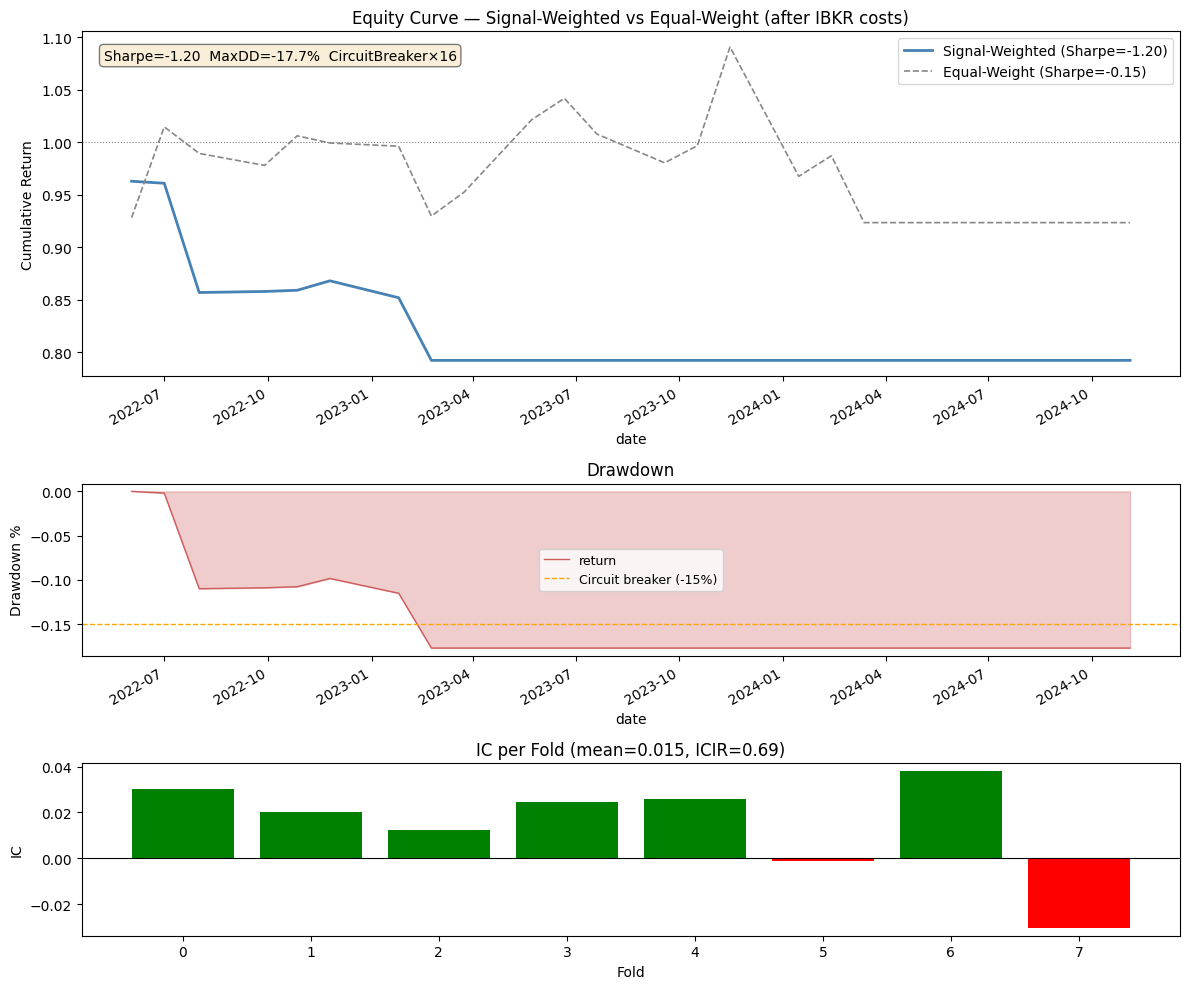

Saved: C:\Users\pc\Documents\Quant Series 2026\ml_stefan_jansen2/equity_curve_v2.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 12 — Backtest: signal-weighted allocation + risk overlay
#            (Jansen MFAT 2e, Ch.12)
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

TOP_DECILE          = 0.10
REBAL_DAYS          = TARGET_HORIZON
COMMISSION_BPS      = 5.0
SLIPPAGE_BPS        = 2.5
TOTAL_COST_BPS      = (COMMISSION_BPS + SLIPPAGE_BPS) * 2

# ── Risk overlay parameters (Jansen Ch.12)
SIGNAL_WEIGHTED    = True    # size proportional to signal strength
MAX_POSITION_SIZE  = 0.05    # max 5% per stock
MAX_MARKET_CONC    = 0.40    # max 40% in any single market (US/HK/MY)
DD_CIRCUIT_BREAKER = -0.15   # skip rebalance if rolling DD < -15%

# ── Build backtest dataframe
bt = pd.DataFrame({
    'date':   fd2['date'].values,
    'ticker': fd2['ticker'].values,
    'actual': y_all.values,
    'signal': oof_preds_filtered.values,
}).dropna(subset=['signal', 'actual'])

def _infer_market(ticker):
    t = str(ticker).upper()
    if t.endswith('.KL') or t.endswith('.KLSE'): return 'MY'
    if t.endswith('.HK'): return 'HK'
    return 'US'

bt['market'] = bt['ticker'].apply(_infer_market)

all_dates   = np.sort(bt['date'].unique())
rebal_dates = all_dates[::REBAL_DAYS]
print(f'Backtest universe (filtered): {len(bt):,} rows, {bt["date"].nunique()} dates, {bt["ticker"].nunique()} tickers')
print(f'Dropped folds {dropped_folds} (< {MIN_TRAIN_DAYS} training days)')
print(f'Rebalance dates: {len(rebal_dates)} (every {REBAL_DAYS} trading days)')

# ── Weight construction helpers
def _cap_weights(w, max_pos):
    w = w.copy()
    for _ in range(30):
        over = w > max_pos
        if not over.any():
            break
        excess = (w[over] - max_pos).sum()
        w[over] = max_pos
        under = ~over
        room = (max_pos - w[under]).sum()
        if room <= 0:
            break
        w[under] += excess * (max_pos - w[under]) / room
    return w / w.sum()

def _build_weights(longs_df):
    n = len(longs_df)
    if SIGNAL_WEIGHTED:
        sig = longs_df['signal'].values.astype(float)
        sig = sig - sig.min()
        w = sig / sig.sum() if sig.sum() > 0 else np.ones(n) / n
    else:
        w = np.ones(n) / n
    w = _cap_weights(w, MAX_POSITION_SIZE)
    markets = longs_df['market'].values
    for _ in range(10):
        mkt_totals = {m: float(w[markets == m].sum()) for m in np.unique(markets)}
        if all(v <= MAX_MARKET_CONC + 1e-9 for v in mkt_totals.values()):
            break
        for m, total in mkt_totals.items():
            if total > MAX_MARKET_CONC:
                w[markets == m] *= MAX_MARKET_CONC / total
        w = w / w.sum()
    return w

# ── Signal-weighted backtest with circuit breaker
period_returns = []
cum_equity  = 1.0
peak_equity = 1.0
circuit_trips = 0

for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date]
    if len(grp) < 10:
        continue
    rolling_dd = (cum_equity / peak_equity) - 1
    if rolling_dd < DD_CIRCUIT_BREAKER:
        circuit_trips += 1
        period_returns.append({'date': rebal_date, 'return': 0.0})
        continue
    threshold = grp['signal'].quantile(1 - TOP_DECILE)
    longs = grp[grp['signal'] >= threshold].copy().reset_index(drop=True)
    if longs.empty:
        continue
    weights   = _build_weights(longs)
    gross_ret = float((longs['actual'].values * weights).sum())
    net_ret   = gross_ret - TOTAL_COST_BPS / 1e4
    cum_equity  = cum_equity * (1 + net_ret)
    peak_equity = max(peak_equity, cum_equity)
    period_returns.append({'date': rebal_date, 'return': net_ret})

perf = pd.DataFrame(period_returns).set_index('date')['return']

print(f"[DIAG] period_returns={len(period_returns)}, ew_returns=will_check_after")
print(f"[DIAG] bt rows={len(bt)}, unique dates={bt['date'].nunique()}, rebal_dates={len(rebal_dates)}")
stocks_per_date = bt.groupby('date').size()
print(f"[DIAG] stocks/date  min={stocks_per_date.min()}, median={stocks_per_date.median():.0f}, dates>=10={( stocks_per_date>=10).sum()}")


# ── Equal-weight baseline (same circuit breaker, for comparison)
ew_returns = []
cum_ew = 1.0
peak_ew = 1.0
for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date]
    if len(grp) < 10:
        continue
    if (cum_ew / peak_ew) - 1 < DD_CIRCUIT_BREAKER:
        ew_returns.append({'date': rebal_date, 'return': 0.0})
        continue
    threshold = grp['signal'].quantile(1 - TOP_DECILE)
    longs = grp[grp['signal'] >= threshold]
    if longs.empty:
        continue
    net_ret = longs['actual'].mean() - TOTAL_COST_BPS / 1e4
    cum_ew  = cum_ew * (1 + net_ret)
    peak_ew = max(peak_ew, cum_ew)
    ew_returns.append({'date': rebal_date, 'return': net_ret})

if ew_returns:
    perf_ew = pd.DataFrame(ew_returns).set_index('date')['return']
    perf_ew = perf_ew.reindex(perf.index, fill_value=0.0)  # align dates to main loop
else:
    perf_ew = pd.Series(0.0, index=perf.index)
    print('WARNING: ew_returns is empty - check bt row counts per date')
print(f"[DIAG] ew_returns={len(ew_returns)}, perf_ew shape={perf_ew.shape}")

# ── Performance stats
cumulative    = (1 + perf).cumprod()
cumulative_ew = (1 + perf_ew).cumprod()
periods_per_year = 252 / REBAL_DAYS
n_years = len(perf) / periods_per_year

sharpe     = float(perf.mean() / perf.std() * np.sqrt(periods_per_year)) if perf.std() > 0 else np.nan
sharpe_ew  = float(perf_ew.mean() / perf_ew.std() * np.sqrt(periods_per_year)) if perf_ew.std() > 0 else np.nan
max_dd     = float((cumulative / cumulative.cummax() - 1).min())
max_dd_ew  = float((cumulative_ew / cumulative_ew.cummax() - 1).min())
ann_return    = float(cumulative.iloc[-1] ** (1 / n_years) - 1) if n_years > 0 else np.nan
ann_return_ew = float(cumulative_ew.iloc[-1] ** (1 / n_years) - 1) if n_years > 0 else np.nan
dd = cumulative / cumulative.cummax() - 1

W = 'Signal-Weighted' if SIGNAL_WEIGHTED else 'Equal-Weight'
print(f'\n{"Metric":<28}  {W:>18}  {"Equal-Weight (base)":>20}')
print('─' * 72)
print(f'{"Annual Sharpe":<28}  {sharpe:>18.2f}  {sharpe_ew:>20.2f}')
print(f'{"Annual Return":<28}  {ann_return*100:>17.1f}%  {ann_return_ew*100:>19.1f}%')
print(f'{"Total Return":<28}  {(cumulative.iloc[-1]-1)*100:>17.1f}%  {(cumulative_ew.iloc[-1]-1)*100:>19.1f}%')
print(f'{"Max Drawdown":<28}  {max_dd*100:>17.1f}%  {max_dd_ew*100:>19.1f}%')
print(f'{"Circuit breaker trips":<28}  {circuit_trips:>18d}')
print(f'{"Backtest period":<28}  {perf.index.min().date()} → {perf.index.max().date()}')
print(f'{"Holding periods":<28}  {len(perf):>18d}')

# ── Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1.5, 1.5]})

cumulative.plot(ax=axes[0], color='steelblue', lw=2,
                label=f'{W} (Sharpe={sharpe:.2f})')
cumulative_ew.plot(ax=axes[0], color='#888888', lw=1.2, ls='--',
                   label=f'Equal-Weight (Sharpe={sharpe_ew:.2f})')
axes[0].set_title(f'Equity Curve — {W} vs Equal-Weight (after IBKR costs)')
axes[0].set_ylabel('Cumulative Return')
axes[0].axhline(1, color='grey', lw=0.8, ls=':')
axes[0].legend(fontsize=10)
txt = f'Sharpe={sharpe:.2f}  MaxDD={max_dd*100:.1f}%'
if circuit_trips:
    txt += f'  CircuitBreaker×{circuit_trips}'
axes[0].text(0.02, 0.95, txt, transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

dd.plot(ax=axes[1], color='indianred', lw=1)
axes[1].fill_between(dd.index, dd, 0, alpha=0.3, color='indianred')
axes[1].axhline(DD_CIRCUIT_BREAKER, color='orange', lw=1, ls='--',
                label=f'Circuit breaker ({DD_CIRCUIT_BREAKER*100:.0f}%)')
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown %')
axes[1].legend(fontsize=9)

colors = ['green' if x > 0 else 'red' for x in res_df['ic']]
axes[2].bar(res_df['fold'], res_df['ic'], color=colors)
axes[2].set_title(f'IC per Fold (mean={res_df.ic.mean():.3f}, ICIR={res_df.ic.mean()/res_df.ic.std():.2f})')
axes[2].set_ylabel('IC')
axes[2].set_xlabel('Fold')
axes[2].axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig(BASE / 'equity_curve_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/equity_curve_v2.png')


SHAP Feature Importance (last fold):
feature  mean_|SHAP|
vol_mom     0.000262


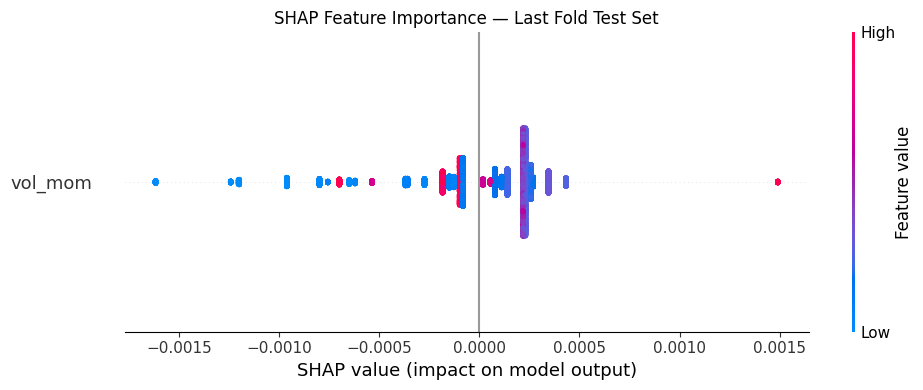

Saved: C:\Users\pc\Documents\Quant Series 2026\ml_stefan_jansen2/shap_importance_v2.png


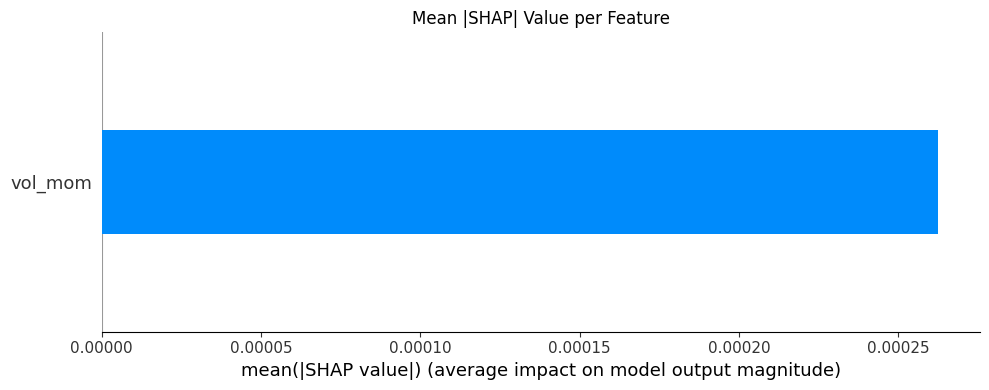

Saved: C:\Users\pc\Documents\Quant Series 2026\ml_stefan_jansen2/shap_bar_v2.png


In [12]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 13 — SHAP Feature Importance (Jansen Ch.12 — model interpretation)
# ═══════════════════════════════════════════════════════════════════════
 
import shap
 
# ── Re-train on the LAST fold (most recent data, most representative)
last_train_idx, last_test_idx = splits[-1]
 
X_tr_shap = np.array(X_all.loc[last_train_idx, selected_features], dtype=float)
y_tr_shap = np.array(y_all.loc[last_train_idx], dtype=float)
X_te_shap = np.array(X_all.loc[last_test_idx, selected_features], dtype=float)
y_te_shap = np.array(y_all.loc[last_test_idx], dtype=float)
 
ok_tr_s = np.isfinite(X_tr_shap).all(axis=1) & np.isfinite(y_tr_shap)
ok_te_s = np.isfinite(X_te_shap).all(axis=1) & np.isfinite(y_te_shap)
X_tr_shap, y_tr_shap = X_tr_shap[ok_tr_s], y_tr_shap[ok_tr_s]
X_te_shap, y_te_shap = X_te_shap[ok_te_s], y_te_shap[ok_te_s]
 
X_tr_shap = np.clip(X_tr_shap, -1e15, 1e15)
X_te_shap = np.clip(X_te_shap, -1e15, 1e15)
 
scaler_shap = RobustScaler()
X_tr_shap = scaler_shap.fit_transform(X_tr_shap)
X_te_shap = scaler_shap.transform(X_te_shap)
 
model_shap = lgb.LGBMRegressor(**LGB_PARAMS)
model_shap.fit(
    X_tr_shap, y_tr_shap,
    eval_set=[(X_te_shap, y_te_shap)],
    callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
)
 
# ── Compute SHAP values on the test set of the last fold
explainer   = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X_te_shap)
 
# ── Mean |SHAP| importance table
shap_importance = pd.DataFrame({
    'feature':    selected_features,
    'mean_|SHAP|': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_|SHAP|', ascending=False).reset_index(drop=True)
 
print('SHAP Feature Importance (last fold):')
print(shap_importance.to_string(index=False))
 
# ── SHAP summary bee-swarm plot
fig_shap, ax_shap = plt.subplots(figsize=(10, max(4, len(selected_features) * 0.4)))
shap.summary_plot(
    shap_values,
    features=X_te_shap,
    feature_names=selected_features,
    show=False,
    plot_size=None,
)
plt.title('SHAP Feature Importance — Last Fold Test Set')
plt.tight_layout()
plt.savefig(BASE / 'shap_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/shap_importance_v2.png')
 
# ── SHAP bar plot (mean |SHAP|)
fig_bar, ax_bar = plt.subplots(figsize=(10, max(4, len(selected_features) * 0.35)))
shap.summary_plot(
    shap_values,
    features=X_te_shap,
    feature_names=selected_features,
    plot_type='bar',
    show=False,
    plot_size=None,
)
plt.title('Mean |SHAP| Value per Feature')
plt.tight_layout()
plt.savefig(BASE / 'shap_bar_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/shap_bar_v2.png')

Top 20 Stocks — Rebalance Date: 2024-11-04
Universe size: 306 stocks

 rank  ticker   signal  signal_z  fwd_return_%
    1     KMB 0.004640     1.489          2.28
    2    NDSN 0.004640     1.489          3.63
    3     PNR 0.004640     1.489          9.14
    4    ISRG 0.004640     1.489          8.38
    5    HOLX 0.004640     1.489         -8.18
    6    OTIS 0.004640     1.489          2.10
    7    SNPS 0.004553    -0.638         12.10
    8     JNJ 0.004553    -0.638         -4.15
    9     PWR 0.004553    -0.638          9.64
   10     BKR 0.004553    -0.638         11.50
   11     HSY 0.004553    -0.638          0.17
   12     MRK 0.004553    -0.638         -0.49
   13     NUE 0.004553    -0.638          4.71
   14     AOS 0.004553    -0.638         -2.05
   15     TMO 0.004553    -0.638         -4.79
   16    ANET 0.004553    -0.638          6.80
   17     AVY 0.004553    -0.638         -0.16
   18     STE 0.004553    -0.638         -3.54
   19 0592.HK 0.004553    -0.638     

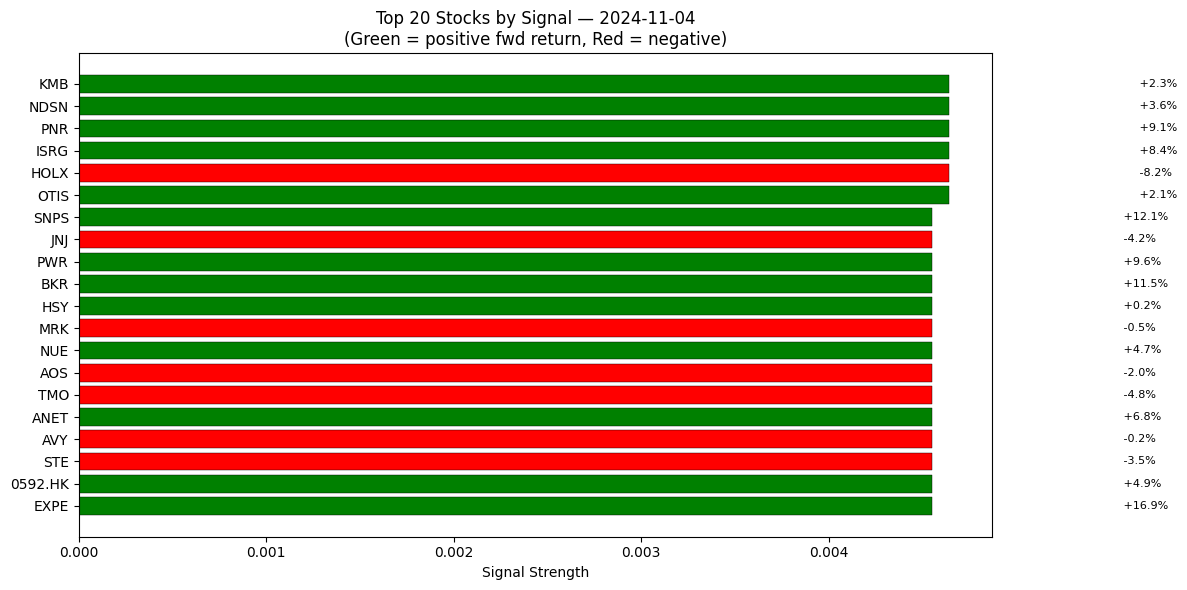

Saved: C:\Users\pc\Documents\Quant Series 2026\ml_stefan_jansen2/top20_stocks_v2.png


In [13]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 14 — Top 20 Stocks by Signal at Latest Rebalance Date
# ═══════════════════════════════════════════════════════════════════════
 
# ── Find the latest rebalance date used in the backtest
latest_rebal = rebal_dates[-1]
 
grp_latest = bt[bt['date'] == latest_rebal].copy()
grp_latest = grp_latest.sort_values('signal', ascending=False)
 
# ── Top 20 by signal
top20 = grp_latest.head(20).copy()
top20['rank'] = range(1, len(top20) + 1)
top20['fwd_return_%'] = (top20['actual'] * 100).round(2)
top20['signal_z'] = ((top20['signal'] - top20['signal'].mean()) / top20['signal'].std()).round(3)
 
print(f'Top 20 Stocks — Rebalance Date: {pd.Timestamp(latest_rebal).date()}')
print(f'Universe size: {len(grp_latest)} stocks\n')
 
display_cols = ['rank', 'ticker', 'signal', 'signal_z', 'fwd_return_%']
print(top20[display_cols].to_string(index=False))
 
# ── Signal decile threshold
threshold_latest = grp_latest['signal'].quantile(1 - TOP_DECILE)
n_selected = (grp_latest['signal'] >= threshold_latest).sum()
print(f'\nTop decile threshold: {threshold_latest:.6f}')
print(f'Stocks in top decile: {n_selected}')
print(f'Mean fwd return (top decile): {grp_latest[grp_latest["signal"] >= threshold_latest]["actual"].mean()*100:.2f}%')
 
# ── Full ranking table (save to CSV for further analysis)
full_ranking = grp_latest[['ticker', 'signal', 'actual']].copy()
full_ranking['rank'] = range(1, len(full_ranking) + 1)
full_ranking['fwd_return_%'] = (full_ranking['actual'] * 100).round(2)
full_ranking.to_csv(BASE / 'stock_ranking_latest.csv', index=False)
print(f'\nFull ranking saved: {BASE}/stock_ranking_latest.csv')
 
# ── Visualise top 20
fig_top, ax_top = plt.subplots(figsize=(12, 6))
colors_top = ['green' if r > 0 else 'red' for r in top20['actual']]
ax_top.barh(
    top20['ticker'].values[::-1],
    top20['signal'].values[::-1],
    color=[c for c in colors_top[::-1]],
    edgecolor='black', linewidth=0.3
)
ax_top.set_xlabel('Signal Strength')
ax_top.set_title(f'Top 20 Stocks by Signal — {pd.Timestamp(latest_rebal).date()}'
                 f'\n(Green = positive fwd return, Red = negative)')
for i, (ticker, sig, ret) in enumerate(
    zip(top20['ticker'].values[::-1], top20['signal'].values[::-1], top20['fwd_return_%'].values[::-1])
):
    ax_top.text(sig + 0.001, i, f' {ret:+.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(BASE / 'top20_stocks_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {BASE}/top20_stocks_v2.png')
 

In [14]:
"""
CELL 15 — Export dashboard data to JSON (v2)
=============================================
Paste this into the notebook as a new cell AFTER Cells 8-14.
All variables (res_df, perf, cumulative, dd, etc.) must be in memory.

This produces dashboard_data.json which dashboard.html consumes.
"""

# ═══════════════════════════════════════════════════════════════════════
# CELL 15 — Export to dashboard_data.json
# ═══════════════════════════════════════════════════════════════════════

import json

print('Exporting dashboard data (v2)...')

# ── 1. Backtest equity curve, drawdown, and per-period returns
#    Also compute GROSS returns for comparison
cost_per_rebal = TOTAL_COST_BPS / 1e4

# Rebuild gross returns by adding cost back
gross_period_returns = perf.values + cost_per_rebal
cumulative_gross = np.cumprod(1 + gross_period_returns)

equity_data = {
    'dates': [str(d.date()) if hasattr(d, 'date') else str(d)[:10] for d in cumulative.index],
    'cumulative': cumulative.values.tolist(),
    'cumulative_gross': cumulative_gross.tolist(),
    'drawdown': dd.values.tolist(),
    'period_returns': perf.values.tolist(),
    'period_returns_gross': gross_period_returns.tolist(),
    'cumulative_ew': cumulative_ew.reindex(cumulative.index).ffill().fillna(1.0).values.tolist(),
    'period_returns_ew': perf_ew.reindex(perf.index).fillna(0.0).values.tolist(),
}

# ── 2. CV fold results  (include train_start/train_end for timeline)
fold_train_dates = {}
for fold_i, (train_idx, _) in enumerate(splits):
    tr_dates = fd2.loc[train_idx, 'date']
    fold_train_dates[fold_i] = (str(tr_dates.min().date()), str(tr_dates.max().date()))

fold_data = []
for _, row in res_df.iterrows():
    fold_i = int(row['fold'])
    ts, te = fold_train_dates.get(fold_i, ('', ''))
    fold_data.append({
        'fold': fold_i,
        'ic': round(float(row['ic']), 4),
        'auc': round(float(row['auc']), 4),
        'n_train': int(row['n_train']),
        'n_test': int(row['n_test']),
        'train_days': int(row['train_days']),
        'train_start': ts,
        'train_end': te,
        'test_start': str(row['test_start']),
        'test_end': str(row['test_end']),
    })

# ── 3. SHAP importance
shap_data = []
for _, row in shap_importance.iterrows():
    shap_data.append({
        'feature': row['feature'],
        'importance': round(float(row['mean_|SHAP|']), 6),
    })

# ── 4. Top stocks at latest rebalance (show top 20 but mark which are in portfolio)
latest_rebal = rebal_dates[-1]
grp_latest = bt[bt['date'] == latest_rebal].copy()
grp_latest = grp_latest.sort_values('signal', ascending=False)
threshold_latest = grp_latest['signal'].quantile(1 - TOP_DECILE)
top_decile_count = int((grp_latest['signal'] >= threshold_latest).sum())

top_stocks_data = []
for i, (_, row) in enumerate(grp_latest.head(20).iterrows()):
    top_stocks_data.append({
        'rank': i + 1,
        'ticker': row['ticker'],
        'signal': round(float(row['signal']), 6),
        'fwd_return_pct': round(float(row['actual']) * 100, 2),
        'in_portfolio': i < top_decile_count,
    })

# ── 5. OOF scatter (subsample for performance)
oof_valid_mask_export = oof_preds_filtered.notna()
oof_sig_vals = signal_winsorised.values
oof_act_vals = y_all[oof_valid_mask_export].values
n_oof = len(oof_sig_vals)
# Subsample to max 2000 points for chart rendering
if n_oof > 2000:
    idx_sample = np.random.RandomState(42).choice(n_oof, 2000, replace=False)
    oof_scatter = [{'signal': round(float(oof_sig_vals[i]), 6), 'actual': round(float(oof_act_vals[i]), 6)} for i in sorted(idx_sample)]
else:
    oof_scatter = [{'signal': round(float(s), 6), 'actual': round(float(a), 6)} for s, a in zip(oof_sig_vals, oof_act_vals)]

# ── 6. Per-rebalance details (n_stocks per period)
rebal_details = []
for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date]
    if len(grp) < 10:
        continue
    thr = grp['signal'].quantile(1 - TOP_DECILE)
    longs = grp[grp['signal'] >= thr]
    if longs.empty:
        continue
    rebal_details.append({
        'date': str(pd.Timestamp(rebal_date).date()),
        'n_stocks': int(len(longs)),
        'n_universe': int(len(grp)),
        'tickers': longs.sort_values('signal', ascending=False)['ticker'].tolist(),
    })

# ── 7. Region breakdown (latest rebalance)
# Infer region from ticker suffix
def get_region(ticker):
    t = str(ticker).upper()
    if t.endswith('.KL') or t.endswith('.KLSE'):
        return 'MY (Bursa)'
    elif t.endswith('.HK'):
        return 'HK (HKEX)'
    elif '.' not in t or t.endswith('.US'):
        return 'US'
    else:
        return 'Other'

portfolio_tickers = grp_latest.head(top_decile_count)['ticker'].tolist()
region_counts = {}
for t in portfolio_tickers:
    r = get_region(t)
    region_counts[r] = region_counts.get(r, 0) + 1

# ── 8. Gross metrics
periods_per_year = 252 / REBAL_DAYS
_sharpe_gross = float(np.mean(gross_period_returns) / np.std(gross_period_returns) * np.sqrt(periods_per_year)) if np.std(gross_period_returns) > 0 else 0
_n_years = len(perf) / periods_per_year
_ann_ret_gross = float(cumulative_gross[-1] ** (1 / _n_years) - 1) if _n_years > 0 else 0

# ── 9. Net metrics
_sharpe = float(perf.mean() / perf.std() * np.sqrt(periods_per_year)) if perf.std() > 0 else 0
_max_dd = float((cumulative / cumulative.cummax() - 1).min())
_ann_ret = float(cumulative.iloc[-1] ** (1 / _n_years) - 1) if _n_years > 0 else 0
_tot_ret = float(cumulative.iloc[-1] - 1)

# OOF IC (from Cell 11)
_ic_oof = float(ic_oof)                # per-date avg (correct)
_ic_oof_pooled = float(ic_oof_pooled)  # pooled (misleading)
_ic_oof_raw = float(ic_oof_raw)        # pooled, all folds (before filter)

# Filtered fold stats
_res_filtered = res_df[res_df['fold'].isin(kept_folds)]
_mean_ic_filtered = float(_res_filtered['ic'].mean())
_icir_filtered = float(_mean_ic_filtered / _res_filtered['ic'].std()) if _res_filtered['ic'].std() > 0 else 0

metrics = {
    'sharpe': round(_sharpe, 2),
    'sharpe_gross': round(_sharpe_gross, 2),
    'annual_return_pct': round(_ann_ret * 100, 1),
    'annual_return_gross_pct': round(_ann_ret_gross * 100, 1),
    'total_return_pct': round(_tot_ret * 100, 1),
    'max_drawdown_pct': round(_max_dd * 100, 1),
    'mean_ic': round(_mean_ic_filtered, 4),
    'icir': round(_icir_filtered, 2),
    'mean_ic_all_folds': round(float(res_df['ic'].mean()), 4),
    'icir_all_folds': round(float(res_df['ic'].mean() / res_df['ic'].std()), 2),
    'oof_signal_ic': round(_ic_oof, 4),
    'oof_signal_ic_pooled': round(_ic_oof_pooled, 4),
    'oof_signal_ic_raw': round(_ic_oof_raw, 4),
    'positive_ic_folds': int((_res_filtered['ic'] > 0).sum()),
    'total_folds': len(_res_filtered),
    'total_folds_all': len(res_df),
    'dropped_folds': len(dropped_folds),
    'min_train_days': int(MIN_TRAIN_DAYS),
    'n_features_selected': len(selected_features),
    'n_features_total': len(passed_features),
    'backtest_start': str(perf.index.min().date()) if hasattr(perf.index.min(), 'date') else str(perf.index.min())[:10],
    'backtest_end': str(perf.index.max().date()) if hasattr(perf.index.max(), 'date') else str(perf.index.max())[:10],
    'holding_periods': len(perf),
    'universe_tickers': int(bt['ticker'].nunique()),
    'universe_rows': len(bt),
    'latest_rebal_date': str(pd.Timestamp(latest_rebal).date()),
    'top_decile_count': top_decile_count,
    'sharpe_ew': round(float(perf_ew.mean() / perf_ew.std() * np.sqrt(periods_per_year)) if perf_ew.std() > 0 else 0, 2),
    'annual_return_ew_pct': round(ann_return_ew * 100, 1) if not np.isnan(ann_return_ew) else 0.0,
    'max_drawdown_ew_pct': round(max_dd_ew * 100, 1),
    'circuit_trips': int(circuit_trips),
    'signal_weighted': bool(SIGNAL_WEIGHTED),
    'max_position_size_pct': round(MAX_POSITION_SIZE * 100, 1),
    'max_market_conc_pct': round(MAX_MARKET_CONC * 100, 1),
    'dd_circuit_breaker_pct': round(DD_CIRCUIT_BREAKER * 100, 1),
}

# ── 10. Config params
config = {
    'TRAIN_PERIOD': int(TRAIN_PERIOD),
    'TEST_PERIOD': int(TEST_PERIOD),
    'TARGET_HORIZON': int(TARGET_HORIZON),
    'EMBARGO': int(EMBARGO),
    'N_SPLITS': int(N_SPLITS),
    'IC_THRESHOLD': float(IC_THRESHOLD),
    'TOP_DECILE': float(TOP_DECILE),
    'REBAL_DAYS': int(REBAL_DAYS),
    'COMMISSION_BPS': float(COMMISSION_BPS),
    'SLIPPAGE_BPS': float(SLIPPAGE_BPS),
    'TOTAL_COST_BPS': float(TOTAL_COST_BPS),
    'SIGNAL_WEIGHTED': bool(SIGNAL_WEIGHTED),
    'MAX_POSITION_SIZE': float(MAX_POSITION_SIZE),
    'MAX_MARKET_CONC': float(MAX_MARKET_CONC),
    'DD_CIRCUIT_BREAKER': float(DD_CIRCUIT_BREAKER),
}

# ── 11. Terminal log
terminal_lines = [
    f'ML matrix: {len(fd2):,} rows × {len(selected_features)} features',
    f'Unique trading dates: {len(np.sort(fd2["date"].unique()))}',
    f'Avg tickers/date: {len(fd2) / len(np.sort(fd2["date"].unique())):.0f}',
    f'Number of CV folds: {len(res_df)}',
    '',
]

for _, row in res_df.iterrows():
    terminal_lines.append(
        f'Fold {int(row["fold"]):2d} | IC={row["ic"]:+.4f}  AUC={row["auc"]:.4f}  '
        f'train={int(row["n_train"]):,} ({int(row["train_days"])}d)  '
        f'test={int(row["n_test"]):,}  '
        f'[{row["test_start"]} → {row["test_end"]}]'
    )

terminal_lines += [
    '',
    f'Mean IC   : {res_df["ic"].mean():.4f}  (ICIR={res_df["ic"].mean()/res_df["ic"].std():.2f})',
    f'Mean AUC  : {res_df["auc"].mean():.4f}',
    f'Positive IC folds: {(res_df["ic"] > 0).sum()}/{len(res_df)}',
    '',
    f'LassoCV selected {len(selected_features)}/{len(passed_features)} features',
    f'Selected: {selected_features}',
    '',
    f'OOF signal IC (signal vs actual): {_ic_oof:.4f}',
    '',
    '── Backtest Results ──',
    f'Backtest universe: {len(bt):,} rows, {bt["date"].nunique()} dates, {bt["ticker"].nunique()} tickers',
    f'Rebalance dates: {len(rebal_dates)} (every {REBAL_DAYS} trading days)',
    f'Annual Sharpe (net) : {_sharpe:.2f}  (gross: {_sharpe_gross:.2f})',
    f'Annual return (net) : {_ann_ret*100:.1f}%  (gross: {_ann_ret_gross*100:.1f}%)',
    f'Total return        : {_tot_ret*100:.1f}%',
    f'Max drawdown        : {_max_dd*100:.1f}%',
    f'Holding periods     : {len(perf)} (non-overlapping)',
    f'Portfolio size      : ~{top_decile_count} stocks (top {TOP_DECILE*100:.0f}%)',
    f'Cost per rebalance  : {TOTAL_COST_BPS:.0f} bps round-trip',
    '',
    '── SHAP Feature Importance ──',
]
for _, row in shap_importance.iterrows():
    terminal_lines.append(f'  {row["feature"]:<20s} {row["mean_|SHAP|"]:.6f}')

terminal_lines += ['', f'── Top {min(20, len(grp_latest))} Stocks (latest rebalance: {pd.Timestamp(latest_rebal).date()}) ──']
for item in top_stocks_data:
    held = ' ← HELD' if item['in_portfolio'] else ''
    terminal_lines.append(
        f'  #{item["rank"]:2d}  {item["ticker"]:<12s}  signal={item["signal"]:.4f}  fwd={item["fwd_return_pct"]:+.1f}%{held}'
    )

terminal_lines += ['', f'── Region Breakdown (portfolio) ──']
for region, count in sorted(region_counts.items()):
    terminal_lines.append(f'  {region:<15s} {count} stocks')

terminal_lines.append('')
terminal_lines.append('Pipeline complete ✓')

# ── Assemble and save
dashboard_data = {
    'generated_at': str(pd.Timestamp.now()),
    'config': config,
    'metrics': metrics,
    'equity': equity_data,
    'folds': fold_data,
    'shap': shap_data,
    'top_stocks': top_stocks_data,
    'top20': top_stocks_data,  # backward compat
    'oof_scatter': oof_scatter,
    'rebal_details': rebal_details,
    'region_breakdown': region_counts,
    'selected_features': selected_features,
    'all_features': list(passed_features),
    'terminal': terminal_lines,
}

out_path = BASE / 'dashboard_data.json'
with open(out_path, 'w') as f:
    json.dump(dashboard_data, f, indent=2, default=str)

print(f'Dashboard data exported → {out_path}')
print(f'  Sharpe: {_sharpe:.2f} (net) / {_sharpe_gross:.2f} (gross)')
print(f'  Return: {_ann_ret*100:.1f}% (net) / {_ann_ret_gross*100:.1f}% (gross)')
print(f'  Folds: {len(fold_data)}  Features: {len(shap_data)}  OOF scatter: {len(oof_scatter)}')
print(f'  Rebalances: {len(rebal_details)}  Regions: {region_counts}')
print(f'\nOpen dashboard.html in your browser, then drop dashboard_data.json onto it.')


Exporting dashboard data (v2)...
Dashboard data exported → C:\Users\pc\Documents\Quant Series 2026\ml_stefan_jansen2\dashboard_data.json
  Sharpe: -1.20 (net) / -1.03 (gross)
  Return: -11.0% (net) / -9.3% (gross)
  Folds: 8  Features: 1  OOF scatter: 2000
  Rebalances: 24  Regions: {'US': 41, 'HK (HKEX)': 2}

Open dashboard.html in your browser, then drop dashboard_data.json onto it.


In [15]:
"""
CELL 15b — Alpha Analysis Export (supplement to Cell 15)
=========================================================
Paste this AFTER Cell 15 in the notebook (or append to the bottom of Cell 15
before the json.dump call).

This adds the following to dashboard_data:
  - quantile_returns    (returns by decile — Alphalens-style)
  - long_short          (top vs bottom decile cumulative)
  - rolling_ic          (cross-sectional IC per rebalance date)
  - turnover            (portfolio turnover per rebalance)
  - factor_autocorrelation (rank autocorrelation of signal)
  - monthly_returns     (year x month returns for heatmap)
  - sortino / calmar    (added to metrics)

Assumes these variables are in memory from earlier cells:
  bt, rebal_dates, perf, cumulative, TOP_DECILE, REBAL_DAYS,
  TOTAL_COST_BPS, dashboard_data, selected_features
"""

import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

print('Exporting alpha analysis data (Cell 15b)...')

# ══════════════════════════════════════════════════════════════
# 1. QUANTILE RETURNS — mean forward return by signal decile
# ══════════════════════════════════════════════════════════════
N_QUANTILES = 10  # deciles

quantile_returns_list = []
for q in range(1, N_QUANTILES + 1):
    quantile_returns_list.append({'label': f'D{q}', 'mean_return': 0.0, 'count': 0, 'total': 0.0})

for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date].copy()
    if len(grp) < N_QUANTILES:
        continue
    grp['quantile'] = pd.qcut(grp['signal'], N_QUANTILES, labels=False, duplicates='drop') + 1
    for q in range(1, N_QUANTILES + 1):
        subset = grp[grp['quantile'] == q]
        if len(subset) > 0:
            avg_ret = subset['actual'].mean()
            quantile_returns_list[q - 1]['total'] += avg_ret
            quantile_returns_list[q - 1]['count'] += 1

for q in quantile_returns_list:
    q['mean_return'] = round(q['total'] / max(q['count'], 1), 6)
    del q['total'], q['count']

print(f'  Quantile returns: {[q["mean_return"] for q in quantile_returns_list]}')

# ══════════════════════════════════════════════════════════════
# 2. LONG-SHORT SPREAD — top vs bottom decile cumulative
# ══════════════════════════════════════════════════════════════
ls_dates = []
ls_top_rets = []
ls_bot_rets = []

for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date].copy()
    if len(grp) < 20:
        continue
    threshold_top = grp['signal'].quantile(1 - TOP_DECILE)
    threshold_bot = grp['signal'].quantile(TOP_DECILE)
    top_grp = grp[grp['signal'] >= threshold_top]
    bot_grp = grp[grp['signal'] <= threshold_bot]
    if len(top_grp) == 0 or len(bot_grp) == 0:
        continue
    ls_dates.append(str(pd.Timestamp(rebal_date).date()))
    ls_top_rets.append(float(top_grp['actual'].mean()))
    ls_bot_rets.append(float(bot_grp['actual'].mean()))

cum_top = list(np.cumprod(1 + np.array(ls_top_rets)))
cum_bot = list(np.cumprod(1 + np.array(ls_bot_rets)))
cum_spread = [round(t - b, 4) for t, b in zip(cum_top, cum_bot)]
cum_top = [round(v, 4) for v in cum_top]
cum_bot = [round(v, 4) for v in cum_bot]

long_short_data = {
    'dates': ls_dates,
    'cum_top': cum_top,
    'cum_bottom': cum_bot,
    'cum_spread': cum_spread,
}

print(f'  Long-short: top final={cum_top[-1]:.2f}x, bottom final={cum_bot[-1]:.2f}x')

# ══════════════════════════════════════════════════════════════
# 3. ROLLING IC — cross-sectional Spearman IC per rebalance
# ══════════════════════════════════════════════════════════════
ric_dates = []
ric_values = []

for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date].copy()
    if len(grp) < 10:
        continue
    # Spearman rank correlation between signal and actual
    corr, _ = spearmanr(grp['signal'].values, grp['actual'].values)
    if not np.isnan(corr):
        ric_dates.append(str(pd.Timestamp(rebal_date).date()))
        ric_values.append(round(float(corr), 4))

# Cumulative mean
ric_cum_mean = []
running_sum = 0
for i, v in enumerate(ric_values):
    running_sum += v
    ric_cum_mean.append(round(running_sum / (i + 1), 4))

rolling_ic_data = {
    'dates': ric_dates,
    'values': ric_values,
    'cumulative_mean': ric_cum_mean,
}

print(f'  Rolling IC: {len(ric_values)} dates, mean={np.mean(ric_values):.4f}')

# ══════════════════════════════════════════════════════════════
# 4. FACTOR TURNOVER — Jaccard distance between consecutive portfolios
# ══════════════════════════════════════════════════════════════
turnover_dates = []
turnover_values = []
prev_portfolio = set()

for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date].copy()
    if len(grp) < 10:
        continue
    threshold = grp['signal'].quantile(1 - TOP_DECILE)
    curr_portfolio = set(grp[grp['signal'] >= threshold]['ticker'].tolist())
    if prev_portfolio:
        # Turnover = fraction of names that changed
        union = prev_portfolio | curr_portfolio
        intersection = prev_portfolio & curr_portfolio
        turnover = 1 - len(intersection) / len(union) if len(union) > 0 else 0
        turnover_dates.append(str(pd.Timestamp(rebal_date).date()))
        turnover_values.append(round(float(turnover), 4))
    prev_portfolio = curr_portfolio

turnover_data = {
    'dates': turnover_dates,
    'values': turnover_values,
}

avg_turnover = np.mean(turnover_values) * 100 if turnover_values else 0
print(f'  Turnover: avg={avg_turnover:.1f}% per rebalance')

# ══════════════════════════════════════════════════════════════
# 5. FACTOR AUTOCORRELATION — rank correlation of signal t vs t-1
# ══════════════════════════════════════════════════════════════
ac_dates = []
ac_values = []
prev_signals = None

for rebal_date in rebal_dates:
    grp = bt[bt['date'] == rebal_date][['ticker', 'signal']].copy()
    if len(grp) < 10:
        continue
    grp = grp.set_index('ticker')['signal']
    if prev_signals is not None:
        common = grp.index.intersection(prev_signals.index)
        if len(common) >= 10:
            corr, _ = spearmanr(grp.loc[common].values, prev_signals.loc[common].values)
            if not np.isnan(corr):
                ac_dates.append(str(pd.Timestamp(rebal_date).date()))
                ac_values.append(round(float(corr), 4))
    prev_signals = grp

autocorr_data = {
    'dates': ac_dates,
    'values': ac_values,
}

avg_ac = np.mean(ac_values) if ac_values else 0
print(f'  Autocorrelation: mean={avg_ac:.3f}')

# ══════════════════════════════════════════════════════════════
# 6. MONTHLY RETURNS — year x month for heatmap
# ══════════════════════════════════════════════════════════════
# Convert period returns to a date-indexed series and resample monthly
perf_series = perf.copy()
if not isinstance(perf_series.index, pd.DatetimeIndex):
    perf_series.index = pd.to_datetime(perf_series.index)

# Compound returns within each month
monthly_cum = (1 + perf_series).groupby([perf_series.index.year, perf_series.index.month]).prod() - 1
monthly_returns_data = []
for (year, month), ret in monthly_cum.items():
    monthly_returns_data.append({
        'year': int(year),
        'month': int(month),
        'ret': round(float(ret), 4),
    })

print(f'  Monthly returns: {len(monthly_returns_data)} months')

# ══════════════════════════════════════════════════════════════
# 7. SORTINO & CALMAR RATIOS — add to metrics
# ══════════════════════════════════════════════════════════════
periods_per_year = 252 / REBAL_DAYS
_perf_vals = perf.values

# Sortino: mean / downside_std * sqrt(periods_per_year)
downside = _perf_vals[_perf_vals < 0]
downside_std = np.std(downside) if len(downside) > 0 else np.std(_perf_vals)
_sortino = float(np.mean(_perf_vals) / downside_std * np.sqrt(periods_per_year)) if downside_std > 0 else 0

# Calmar: annual_return / abs(max_drawdown)
_ann_ret_for_calmar = dashboard_data['metrics']['annual_return_pct'] / 100
_max_dd_for_calmar = abs(dashboard_data['metrics']['max_drawdown_pct'] / 100)
_calmar = float(_ann_ret_for_calmar / _max_dd_for_calmar) if _max_dd_for_calmar > 0 else 0

print(f'  Sortino: {_sortino:.2f}  Calmar: {_calmar:.2f}')

# ══════════════════════════════════════════════════════════════
# PATCH dashboard_data and re-save
# ══════════════════════════════════════════════════════════════
dashboard_data['quantile_returns'] = quantile_returns_list
dashboard_data['long_short'] = long_short_data
dashboard_data['rolling_ic'] = rolling_ic_data
dashboard_data['turnover'] = turnover_data
dashboard_data['factor_autocorrelation'] = autocorr_data
dashboard_data['monthly_returns'] = monthly_returns_data
dashboard_data['metrics']['sortino'] = round(_sortino, 2)
dashboard_data['metrics']['calmar'] = round(_calmar, 2)

out_path = BASE / 'dashboard_data.json'
with open(out_path, 'w') as f:
    json.dump(dashboard_data, f, indent=2, default=str)

print(f'\nAlpha analysis data added to {out_path}')
print(f'  Quantile spread (D10-D1): {(quantile_returns_list[-1]["mean_return"] - quantile_returns_list[0]["mean_return"])*100:.3f}%')
print(f'  Mean rolling IC: {np.mean(ric_values):.4f}')
print(f'  Avg turnover: {avg_turnover:.1f}%')
print(f'  Mean autocorrelation: {avg_ac:.3f}')
print(f'  Sortino: {_sortino:.2f}  Calmar: {_calmar:.2f}')

Exporting alpha analysis data (Cell 15b)...
  Quantile returns: [np.float64(-0.007641), np.float64(0.0041), np.float64(-0.004214), np.float64(0.003505), np.float64(0.008978), np.float64(0.02341), np.float64(0.012312), np.float64(-0.001028), np.float64(0.000558), np.float64(0.015162)]
  Long-short: top final=1.09x, bottom final=0.80x
  Rolling IC: 24 dates, mean=0.0388
  Turnover: avg=90.2% per rebalance
  Autocorrelation: mean=-0.069
  Monthly returns: 24 months
  Sortino: -0.85  Calmar: -0.62

Alpha analysis data added to C:\Users\pc\Documents\Quant Series 2026\ml_stefan_jansen2\dashboard_data.json
  Quantile spread (D10-D1): 2.280%
  Mean rolling IC: 0.0388
  Avg turnover: 90.2%
  Mean autocorrelation: -0.069
  Sortino: -0.85  Calmar: -0.62
